# MSAAI 511 Final Project — MIDI Composer Classification





## Abstract

This project classifies classical MIDI compositions among four composers (Bach, Beethoven,
Chopin, Mozart) using 58 hand-engineered musical descriptors (pitch, rhythm, dynamics, harmony,
and instrumentation statistics) extracted per composition. A team-sourced imbalance-correction
effort added Beethoven/Chopin/Mozart compositions from several public MIDI collections, improving
the Bach:Chopin train-set ratio from roughly 7.5:1 to 3.2:1. Two neural architectures — a 1D CNN
treating the feature vector as an ordered sequence, and an LSTM treating each composition as a
single-timestep gated classifier — are trained with class-weighted loss and evaluated on a
held-out test set with accuracy, macro-averaged precision/recall/F1, ROC-AUC, confusion matrices,
permutation feature importance, and SHAP. The CNN is the stronger model on this feature
representation; per-class results show the imbalance correction, not architecture choice, drives
most of the improvement over the original single-source dataset.

## Project description

- **Problem**: 4-way composer classification from MIDI files, framed as a supervised
  classification task over per-composition numeric features (not raw audio or symbolic sequences).
- **Dataset provenance**: an original `midiclassics` corpus plus 8 additional harvested sources
  (Hugging Face datasets, Kaggle, piano-midi.de, Wikimedia Commons, and others), deduplicated by a
  MIDI-signature fingerprint before feature extraction.
- **Feature schema**: 63 CSV columns per composition — 3 identifiers (`composer`, `filename`,
  `relative_path`) plus 60 numeric descriptors covering pitch/pitch-class statistics, rhythm and
  timing, dynamics (velocity), harmony (chord counts), polyphony, and General MIDI instrumentation.
- **Modeling approach**: 1D CNN vs. LSTM over the standardized 58-feature vector (2 columns are
  constant in the training split and dropped), class-weighted training, held-out test evaluation.
- **Headline result**: see Section 15 (Consolidated Observations) for the numbers from this run.


## Table of contents

0. Front matter (this section) &nbsp;&nbsp; 
1. Environment & configuration &nbsp;&nbsp;
2. Data acquisition &nbsp;&nbsp; 
3. Feature extraction &nbsp;&nbsp; 
4. Data cleaning & dedup &nbsp;&nbsp;
5. Incremental feature generation &nbsp;&nbsp; 
6. Merge & validation &nbsp;&nbsp;
7. Exploratory data analysis &nbsp;&nbsp; 
8. Preprocessing & scaling &nbsp;&nbsp;
9. Model building &nbsp;&nbsp; 
10. Model training &nbsp;&nbsp; 
11. Held-out test evaluation &nbsp;&nbsp;
12. Extended evaluation (test vs. validation) &nbsp;&nbsp;
13. Hyperparameter tuning &nbsp;&nbsp; 
14. Reproducibility & metric reconciliation &nbsp;&nbsp;
15. Consolidated observations &nbsp;&nbsp; 
16. Conclusion &nbsp;&nbsp; 
17. Limitations & future work &nbsp;&nbsp;
18. Attribution & reproducibility manifest

## 1. Environment & Global Configuration

This section establishes the runtime environment and shared configuration used throughout the
notebook, so that later sections can assume a consistent, reproducible starting state.

- **Library imports and global seeding.** All third-party libraries used across the notebook
  (pandas, NumPy, TensorFlow/Keras, scikit-learn, Keras Tuner, seaborn/matplotlib) are imported
  once at the top, and a single random seed (`SEED = 42`) is applied to Python's `random`, NumPy,
  `PYTHONHASHSEED`, and TensorFlow's global seed, so that results are reproducible across
  notebook restarts.
- **Shared plotting style.** A single seaborn theme and pandas display format are set once for
  the entire notebook, avoiding inconsistent plot styling between sections originally authored
  separately.
- **Path constants and output directories.** Paths to the feature CSVs, split plan, and a
  dedicated output folder (`final_submission_outputs_tuned/`) are defined, keeping this run's
  artifacts separate from prior standalone-notebook runs used later for reconciliation
  (Section 14).
- **Preflight data-availability audit.** Presence of the original feature CSVs, harvested
  feature CSVs, combined feature CSVs, split plan, and raw MIDI folders is checked
  programmatically, determining which downstream sections (2-5) can be live-executed versus
  documented as reference-only code.

In [ ]:
"""Environment setup and global configuration for the notebook.Sets a
single global random seed, and defines shared path/logging utilities used throughout.
"""
import hashlib
import json
import os
import random
import warnings
from pathlib import Path

import joblib
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score, auc, classification_report, confusion_matrix,
    precision_recall_fscore_support, roc_curve,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Conv1D, Dense, Dropout, Flatten, Input, LSTM, MaxPooling1D
from tensorflow.keras.regularizers import l2

warnings.filterwarnings("ignore", category=FutureWarning)

# One shared plot style for the whole notebook
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("Python/TensorFlow environment:")
print("  TensorFlow:", tf.__version__)
print("  scikit-learn features available:", True)
print("  GPU devices:", tf.config.list_physical_devices("GPU"))


def log(stage, message):
    """Print a timestamped, stage-labeled log line.

    Used to bracket sections of original authors' code with explanatory context, without
    editing their function bodies. Google-style docstring per project documentation standard.

    Args:
        stage: Short section label, e.g. "SECTION 6 (Jacob)".
        message: Human-readable status message.
    """
    print(f"[{stage}] {message}")

Python/TensorFlow environment:
  TensorFlow: 2.21.0
  scikit-learn features available: True


  GPU devices: []


In [ ]:
"""Path constants and output directories.All artifacts from this notebook are written under a dedicated output folder
"""
PROJECT_ROOT = Path.cwd().resolve()
REPO_ROOT = PROJECT_ROOT.parent if PROJECT_ROOT.name == "composer_model_project" else PROJECT_ROOT
FEATURE_DIR = REPO_ROOT / "data" / "features"
ORIGINAL_FEATURE_DIR = FEATURE_DIR / "original features"
SPLIT_PLAN_PATH = REPO_ROOT / "data" / "split_plans" / "candidate_split_plan.csv"

RUN_LABEL = "tuned"
OUTPUT_DIR = PROJECT_ROOT / f"final_submission_outputs_{RUN_LABEL}"
OUTPUT_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR = OUTPUT_DIR / "models"
ARTIFACT_DIR.mkdir(exist_ok=True)

BASELINE_METRICS_DIR = PROJECT_ROOT / "evaluation_outputs"
BASELINE_TUNED_METRICS_DIR = PROJECT_ROOT / "evaluation_outputs_tuned"

log("SECTION 1", f"PROJECT_ROOT={PROJECT_ROOT}")
log("SECTION 1", f"REPO_ROOT={REPO_ROOT}")
log("SECTION 1", f"Outputs will be written to {OUTPUT_DIR}")

[SECTION 1] PROJECT_ROOT=C:\mycode\msaai511-finalproject\MIDI-Composer-Classification\composer_model_project
[SECTION 1] REPO_ROOT=C:\mycode\msaai511-finalproject\MIDI-Composer-Classification
[SECTION 1] Outputs will be written to C:\mycode\msaai511-finalproject\MIDI-Composer-Classification\composer_model_project\final_submission_outputs_tuned


In [ ]:
"""Preflight data-availability audit.
"""
def check_path(label, path):
    exists = Path(path).exists()
    print(f"  [{'OK' if exists else 'MISSING'}] {label}: {path}")
    return exists

print("Data-availability audit:")
HAS_ORIGINAL_FEATURES = check_path("original features CSVs", ORIGINAL_FEATURE_DIR / "train_features.csv")
HAS_NEW_FEATURES = check_path("new_*_features.csv", FEATURE_DIR / "new_train_features.csv")
HAS_COMBINED_FEATURES = check_path("combined_*_features.csv", FEATURE_DIR / "combined_train_features.csv")
HAS_SPLIT_PLAN = check_path("candidate_split_plan.csv", SPLIT_PLAN_PATH)
HAS_RAW_MIDICLASSICS = check_path("data/midiclassics/ (original raw MIDI)", REPO_ROOT / "data" / "midiclassics")
HAS_RAW_NEW_MIDI = check_path("data/new_midi_files/ (harvested raw MIDI)", REPO_ROOT / "data" / "new_midi_files")
HAS_BACKUP_MIDI = check_path("backup/midiclassics/ (recovered partial copy, outside repo)",
                              REPO_ROOT.parent / "backup" / "midiclassics")

print()
print("Consequence: Sections 2-5 (data acquisition, raw feature extraction, ingestion/dedup,")
print("incremental feature generation) depend on the MISSING raw MIDI folders and are shown as")
print("documented reference code, not executed. Sections 6 onward depend only on the present")
print("feature CSVs and split plan, and ARE live-executed below.")

Data-availability audit:
  [OK] original features CSVs: C:\mycode\msaai511-finalproject\MIDI-Composer-Classification\data\features\original features\train_features.csv
  [OK] new_*_features.csv: C:\mycode\msaai511-finalproject\MIDI-Composer-Classification\data\features\new_train_features.csv
  [OK] combined_*_features.csv: C:\mycode\msaai511-finalproject\MIDI-Composer-Classification\data\features\combined_train_features.csv
  [OK] candidate_split_plan.csv: C:\mycode\msaai511-finalproject\MIDI-Composer-Classification\data\split_plans\candidate_split_plan.csv
  [MISSING] data/midiclassics/ (original raw MIDI): C:\mycode\msaai511-finalproject\MIDI-Composer-Classification\data\midiclassics
  [MISSING] data/new_midi_files/ (harvested raw MIDI): C:\mycode\msaai511-finalproject\MIDI-Composer-Classification\data\new_midi_files
  [OK] backup/midiclassics/ (recovered partial copy, outside repo): C:\mycode\msaai511-finalproject\backup\midiclassics

Consequence: Sections 2-5 (data acquisition, raw

## 2. Data Acquisition
Three public MIDI collections were downloaded from the Hugging Face Hub to supplement the
original `midiclassics` corpus for the under-represented composers (Beethoven, Chopin, Mozart).

- **Source inventory reconstruction.** Since the original download step requires network access
  unavailable in this checkout, the full eight-source acquisition inventory is reconstructed
  instead from `candidate_split_plan.csv`, which records every file the ingestion step
  (Section 4) actually scanned, including the five sources not covered by the Hugging Face
  download step alone. This yields a live, verifiable count (1,329 candidate files across eight
  source folders) without requiring the original network call to be re-executed.

In [5]:
"""Derived, live verification: reconstruct the full 8-source acquisition inventory from
`candidate_split_plan.csv`, which records every file the ingestion step (Section 4) actually
scanned - including the 5 sources not covered by huggingface.ipynb above."""
if HAS_SPLIT_PLAN:
    plan_df = pd.read_csv(SPLIT_PLAN_PATH)
    source_inventory = (
        plan_df.groupby(["source", "composer"], observed=True)
               .size()
               .unstack(fill_value=0)
               .reindex(columns=["Beethoven", "Chopin", "Mozart"], fill_value=0)
               .sort_index()
    )
    log("SECTION 2", f"{len(plan_df):,} candidate files scanned across {plan_df['source'].nunique()} source folders")
    display(source_inventory)
else:
    log("SECTION 2", "candidate_split_plan.csv not found - skipping derived inventory")

[SECTION 2] 1,329 candidate files scanned across 8 source folders


composer,Beethoven,Chopin,Mozart
source,,,
BigSynthPiano,238,0,0
ChoralTech.us,5,0,87
Classical Music MIDI (Kaggle),0,48,21
chopin-comp-midi,0,130,0
commons.wikimedia.org,29,10,33
midi-classical-music,219,136,257
midisheetmusic.com,4,10,6
piano-midi.de,29,46,21


## 3. Feature Extraction


Builds the original 63-column feature schema from raw MIDI files: 3 identifier columns
(`composer`, `filename`, `relative_path`) plus 60 numeric descriptors — pitch/pitch-class
statistics, rhythm and timing, dynamics, chord/harmony counts, polyphony (via a sweep-line
algorithm over note on/off events), and General MIDI instrumentation family counts. The
extraction is idempotent: a base pass only runs if the split CSVs are missing, and an enrichment
pass only fills missing/incomplete derived columns.

- **Reference feature-extraction code.** The `extract_features`, `split_files`, and
  `process_dataset` routines that build the base schema from raw MIDI files are preserved as
  disabled reference code and are not executed, since the raw MIDI corpus is not present in this
  checkout; they are retained for attribution and completeness.
- **Derived-feature recomputation check.** Eight engineered features that depend on the base
  schema (pitch entropy, pitch-class variance, normalized pitch range, chord density, velocity
  variation, tempo/note ratio, chromatic ratio, notes-per-chord) are recomputed directly from the
  shipped `combined_train_features.csv` and compared against the stored column values. All eight
  checks pass, confirming the feature-engineering formulas match the data on disk without
  requiring any raw MIDI file.

In [6]:
%%script false --no-raise-error
# REFERENCE ONLY - not executed in this run (see markdown above for why)
import os
import pandas as pd
import numpy as np

import music21
import pretty_midi
from music21 import converter, chord

BASE_DIR = "../data/midiclassics"
OUTPUT_DIR_ORIG = "../data/features/original features"
SPLIT_RATIOS = {"train": 0.70, "dev": 0.15, "test": 0.15}
COMPOSERS_ALL = ["Bach", "Beethoven", "Chopin", "Mozart"]


def extract_features(filepath, composer):
    """Extract per-composition MIDI features for one file.

    Loads the file with pretty_midi for note/pitch/velocity/duration statistics and tempo,
    and separately with music21 to chordify the score and count chords (the slow step).

    Args:
        filepath: Path to a .mid/.midi file.
        composer: Ground-truth composer label to attach to the resulting row.

    Returns:
        A dict of feature name -> value, or None if the file has no notes or fails to parse.
    """
    try:
        midi = pretty_midi.PrettyMIDI(filepath)
        notes, durations, velocities = [], [], []
        for instrument in midi.instruments:
            for note in instrument.notes:
                notes.append(note.pitch)
                durations.append(note.end - note.start)
                velocities.append(note.velocity)
        if len(notes) == 0:
            return None

        tempo = midi.estimate_tempo()
        pitch_hist = midi.get_pitch_class_histogram()
        note_density = len(notes) / midi.get_end_time()
        avg_pitch = np.mean(notes)
        pitch_range = np.max(notes) - np.min(notes)
        avg_duration = np.mean(durations)
        avg_velocity = np.mean(velocities)

        # Count chords using music21 (the slow step).
        score = converter.parse(filepath)
        chords = score.chordify()
        chord_count = sum(1 for c in chords.recurse().getElementsByClass(chord.Chord))

        features = {
            "composer": composer, "filename": os.path.basename(filepath), "tempo": tempo,
            "num_notes": len(notes), "num_chords": chord_count, "avg_pitch": avg_pitch,
            "pitch_range": pitch_range, "avg_duration": avg_duration,
            "avg_velocity": avg_velocity, "note_density": note_density,
        }
        for i in range(12):
            features[f"pitch_class_{i}"] = pitch_hist[i]
        return features
    except Exception as e:
        print(f"Error reading {filepath}")
        print(e)
        return None


def split_files(files, rng):
    """Shuffle and split a composer's file list 70/15/15 into train/dev/test.

    Args:
        files: Iterable of file paths for one composer.
        rng: A numpy Generator used for the shuffle (caller controls the seed).

    Returns:
        Dict with keys "train"/"dev"/"test" mapping to lists of file paths.
    """
    files = list(files)
    rng.shuffle(files)
    train_end = int(len(files) * SPLIT_RATIOS["train"])
    dev_end = train_end + int(len(files) * SPLIT_RATIOS["dev"])
    return {"train": files[:train_end], "dev": files[train_end:dev_end], "test": files[dev_end:]}


def process_dataset():
    """Walk BASE_DIR/<composer>, extract features for every MIDI file, and write 3 split CSVs."""
    rows_by_split = {split: [] for split in SPLIT_RATIOS}
    rng = np.random.default_rng(42)
    for composer in COMPOSERS_ALL:
        composer_folder = os.path.join(BASE_DIR, composer)
        midi_files = [
            os.path.join(root, file) for root, _, files in os.walk(composer_folder)
            for file in files if file.lower().endswith((".mid", ".midi"))
        ]
        if not midi_files:
            print(f"No MIDI files found for {composer}; skipping.")
            continue
        print(f"Processing {composer}: {len(midi_files)} files")
        for split, files in split_files(midi_files, rng).items():
            for filepath in files:
                features = extract_features(filepath, composer)
                if features is not None:
                    rows_by_split[split].append(features)
    os.makedirs(OUTPUT_DIR_ORIG, exist_ok=True)
    for split, rows in rows_by_split.items():
        output = os.path.join(OUTPUT_DIR_ORIG, f"{split}_features.csv")
        pd.DataFrame(rows).to_csv(output, index=False)
        print(f"Saved {len(rows)} rows to {output}")


expected_splits = [os.path.join(OUTPUT_DIR_ORIG, f"{split}_features.csv") for split in SPLIT_RATIOS]
if all(os.path.exists(path) for path in expected_splits):
    print("Existing feature CSVs found; skipping base extraction and preserving current splits.")
else:
    process_dataset()

In [7]:
"""Derived, live verification: recompute Jacob's 8 derived-feature formulas
(add_dataframe_features in MIDI_Extract.ipynb) directly from the shipped combined_train
CSV and confirm they match the stored values. This exercises the actual feature-engineering
math without requiring any raw MIDI file."""
_verify_df = pd.read_csv(FEATURE_DIR / "combined_train_features.csv") if HAS_COMBINED_FEATURES else None

if _verify_df is not None:
    _pitch_cols = [f"pitch_class_{i}" for i in range(12)]
    _pitch_vals = _verify_df[_pitch_cols].to_numpy(dtype=float)
    _pitch_probs = _pitch_vals / (_pitch_vals.sum(axis=1, keepdims=True) + 1e-10)
    _chromatic_idx = [1, 3, 6, 8, 10]

    _recomputed = {
        "pitch_entropy": -np.sum(_pitch_probs * np.log(_pitch_probs + 1e-10), axis=1),
        "pitch_class_variance": np.var(_pitch_vals, axis=1),
        "range_normalized": _verify_df["pitch_range"] / (_verify_df["avg_pitch"] + 1e-6),
        "notes_per_chord": _verify_df["num_notes"] / (_verify_df["num_chords"] + 1),
        "chord_density": _verify_df["num_chords"] / (_verify_df["num_notes"] + 1),
        "velocity_variation": _verify_df["avg_velocity"] / (_verify_df["tempo"] + 1),
        "tempo_note_ratio": _verify_df["tempo"] / (_verify_df["num_notes"] + 1),
        "chromatic_ratio": _pitch_vals[:, _chromatic_idx].sum(axis=1) / (_pitch_vals.sum(axis=1) + 1e-6),
    }
    print("Recomputed-vs-stored derived feature check (combined_train_features.csv):")
    for name, values in _recomputed.items():
        matches = np.allclose(np.asarray(values), _verify_df[name].to_numpy(), rtol=1e-4, atol=1e-6)
        print(f"  {name:22s} matches stored column: {matches}")
else:
    log("SECTION 3", "combined_train_features.csv not found - skipping derived-feature check")

Recomputed-vs-stored derived feature check (combined_train_features.csv):
  pitch_entropy          matches stored column: True
  pitch_class_variance   matches stored column: True
  range_normalized       matches stored column: True
  notes_per_chord        matches stored column: True
  chord_density          matches stored column: True
  velocity_variation     matches stored column: True
  tempo_note_ratio       matches stored column: True
  chromatic_ratio        matches stored column: True


## 4. Data Cleaning: Deduplication & Split Planning

Scans every subfolder of `data/new_midi_files/` (the harvested collections), fingerprints each
MIDI file by `(duration, tempo, num_notes, notes_per_second)`, and compares against the existing
`data/midiclassics/{Beethoven,Chopin,Mozart}` corpus (treated as canonical/"already kept").
Files matching an existing fingerprint are marked duplicates; the first novel occurrence per
fingerprint is kept and assigned a deterministic hash-based 70/15/15 split. **Note the deliberate
asymmetry: `COMPOSERS` here is `('Beethoven', 'Chopin', 'Mozart')` — Bach was not part of this
ingestion effort**, which is why Bach's count is unchanged between the original and combined
datasets.

- **Reference deduplication code.** The fingerprinting and hash-based split-assignment logic
  that produces `candidate_split_plan.csv` is preserved as disabled reference code and is not
  executed, since the raw MIDI folders are not present in this checkout.
- **Status-breakdown verification.** The already-produced split plan is loaded and its
  per-composer keep/duplicate status breakdown is reproduced, confirming that 611 of 1,329
  candidate files (46.0%) were kept and the remainder rejected as duplicates of the existing
  corpus.
- **Plan-to-CSV reconciliation.** Kept-row counts implied by the split plan are compared, per
  composer and per split, against the actual `new_{train,dev,test}_features.csv` row counts
  produced downstream (Section 5), and reconcile exactly, confirming the split plan and the
  feature-generation step it drives are consistent with one another.

In [8]:
%%script false --no-raise-error
# REFERENCE ONLY - not executed in this run (see markdown above for why)
from pathlib import Path
import hashlib

import pandas as pd
import pretty_midi

COMPOSERS_INGEST = ("Beethoven", "Chopin", "Mozart")  # Bach intentionally excluded
PREFERRED_DIRS = {composer: Path("../data/midiclassics") / composer for composer in COMPOSERS_INGEST}
NEW_DATA_DIR = Path("../data/new_midi_files")
MIDI_SUFFIXES = {".mid", ".midi"}
SPLIT_PLAN_PATH_REF = Path("../data/split_plans/candidate_split_plan.csv")


def midi_files(directory):
    """List all .mid/.midi files under a directory, recursively, sorted."""
    return sorted(p for p in directory.rglob("*") if p.is_file() and p.suffix.casefold() in MIDI_SUFFIXES)


def source_folders():
    """List each immediate subfolder of NEW_DATA_DIR - one per harvested source collection."""
    if not NEW_DATA_DIR.is_dir():
        raise FileNotFoundError(f"Create the new-data folder first: {NEW_DATA_DIR.resolve()}")
    return sorted((p for p in NEW_DATA_DIR.iterdir() if p.is_dir()), key=lambda p: p.name.casefold())


def composer_from_path(path):
    """Infer the composer from a file's name or enclosing folder names (case-insensitive)."""
    parts = [path.stem, *path.relative_to(NEW_DATA_DIR).parts[:-1]]
    normalized_parts = [part.casefold() for part in parts]
    for composer in COMPOSERS_INGEST:
        name = composer.casefold()
        if any(name == part or name in part for part in normalized_parts):
            return composer
    return None


def feature_record(path, source, composer):
    """Compute a dedup fingerprint (duration, tempo, note count, notes/sec) for one MIDI file."""
    midi = pretty_midi.PrettyMIDI(str(path))
    duration = midi.get_end_time()
    num_notes = sum(len(instrument.notes) for instrument in midi.instruments)
    if duration <= 0 or num_notes == 0:
        raise ValueError("MIDI has no timed notes")
    tempo = midi.estimate_tempo()
    notes_per_second = num_notes / duration
    signature = (round(duration, 6), round(tempo, 6), num_notes, round(notes_per_second, 9))
    return {"source": source, "composer": composer, "path": path, "total_duration": duration,
            "estimated_tempo": tempo, "num_notes": num_notes, "notes_per_second": notes_per_second,
            "feature_signature": signature}


def collect_records(directory, source, fixed_composer=None):
    """Build fingerprint records for every MIDI file in a directory, tracking errors/ignored files."""
    records, errors, ignored = [], [], []
    for path in midi_files(directory):
        composer = fixed_composer or composer_from_path(path)
        if composer not in COMPOSERS_INGEST:
            ignored.append({"source": source, "path": str(path), "reason": "composer_not_identified"})
            continue
        try:
            records.append(feature_record(path, source, composer))
        except Exception as error:
            errors.append({"source": source, "composer": composer, "path": str(path), "error": str(error)})
    return records, errors, ignored


def assigned_split(composer, signature):
    """Deterministically assign train/dev/test via a SHA-256 hash of (composer, signature)."""
    value = int(hashlib.sha256(repr((composer, signature)).encode()).hexdigest()[:8], 16) % 100
    return "train" if value < 70 else "dev" if value < 85 else "test"


# Build the canonical (already-kept) fingerprint set from data/midiclassics.
preferred_by_key, errors = {}, []
for composer, directory in PREFERRED_DIRS.items():
    records, source_errors, _ = collect_records(directory, "midiclassics", composer)
    errors.extend(source_errors)
    for record in records:
        preferred_by_key.setdefault((composer, record["feature_signature"]), []).append(record["path"])

# Build the candidate set from every harvested source folder.
candidate_by_key, ignored = {}, []
for source_directory in source_folders():
    source = source_directory.name
    records, source_errors, source_ignored = collect_records(source_directory, source)
    errors.extend(source_errors)
    ignored.extend(source_ignored)
    for record in records:
        candidate_by_key.setdefault((record["composer"], record["feature_signature"]), []).append(record)

priority = {source: rank for rank, source in enumerate(
    sorted({r["source"] for records in candidate_by_key.values() for r in records}, key=str.casefold))}
plan = []
for (composer, signature), records in candidate_by_key.items():
    records.sort(key=lambda r: (priority[r["source"]], str(r["path"]).casefold()))
    preferred_paths = preferred_by_key.get((composer, signature), [])
    keeper = None if preferred_paths else records[0]
    for record in records:
        if preferred_paths:
            status, duplicate_of, split = "duplicate_of_midiclassics", " | ".join(map(str, preferred_paths)), None
        elif record is keeper:
            status = "keep_unique" if len(records) == 1 else "keep_candidate_representative"
            duplicate_of, split = "", assigned_split(composer, signature)
        else:
            status, duplicate_of, split = "duplicate_of_candidate", str(keeper["path"]), None
        plan.append({"source": record["source"], "composer": composer, "path": str(record["path"]),
                     "status": status, "duplicate_of": duplicate_of, "recommended_split": split,
                     "total_duration": record["total_duration"], "estimated_tempo": record["estimated_tempo"],
                     "num_notes": record["num_notes"], "notes_per_second": record["notes_per_second"]})

report = pd.DataFrame(plan).sort_values(["composer", "status", "source", "path"], ignore_index=True)
error_report = pd.DataFrame(errors)
ignored_report = pd.DataFrame(ignored)
SPLIT_PLAN_PATH_REF.parent.mkdir(parents=True, exist_ok=True)
report.to_csv(SPLIT_PLAN_PATH_REF, index=False)
display(report)
display(report.groupby(["composer", "status"]).size().rename("files").to_frame())
print(f"Scanned {len(source_folders()):,} source folders; saved {len(report):,} planned files. No MIDI files were deleted.")

In [9]:
"""Derived, live verification: load the split plan that MIDI_Ingest.ipynb already produced,
reproduce its status-breakdown summary, and reconcile the kept-row counts against the actual
new_*_features.csv files produced downstream (Section 5)."""
if HAS_SPLIT_PLAN:
    plan_df = pd.read_csv(SPLIT_PLAN_PATH)
    status_breakdown = plan_df.groupby(["composer", "status"], observed=True).size().unstack(fill_value=0)
    display(status_breakdown)

    total = len(plan_df)
    duplicates = plan_df["status"].isin(["duplicate_of_midiclassics", "duplicate_of_candidate"]).sum()
    kept = plan_df["status"].isin(["keep_unique", "keep_candidate_representative"]).sum()
    log("SECTION 4", f"{total:,} candidates scanned: {kept:,} kept ({kept/total:.1%}), "
                      f"{duplicates:,} rejected as duplicates ({duplicates/total:.1%})")

    if HAS_NEW_FEATURES:
        kept_by_split = (
            plan_df[plan_df["status"].isin(["keep_unique", "keep_candidate_representative"])]
            .groupby(["composer", "recommended_split"], observed=True).size().unstack(fill_value=0)
        )
        new_train = pd.read_csv(FEATURE_DIR / "new_train_features.csv")["composer"].value_counts()
        new_dev = pd.read_csv(FEATURE_DIR / "new_dev_features.csv")["composer"].value_counts()
        new_test = pd.read_csv(FEATURE_DIR / "new_test_features.csv")["composer"].value_counts()
        reconciliation = pd.DataFrame({
            "plan_train": kept_by_split.get("train", pd.Series(dtype=int)),
            "csv_train": new_train, "plan_dev": kept_by_split.get("dev", pd.Series(dtype=int)),
            "csv_dev": new_dev, "plan_test": kept_by_split.get("test", pd.Series(dtype=int)),
            "csv_test": new_test,
        }).fillna(0).astype(int)
        display(reconciliation)
        matches = (
            (reconciliation["plan_train"] == reconciliation["csv_train"]).all()
            and (reconciliation["plan_dev"] == reconciliation["csv_dev"]).all()
            and (reconciliation["plan_test"] == reconciliation["csv_test"]).all()
        )
        log("SECTION 4", f"Plan-to-CSV row counts reconcile exactly: {matches}")
else:
    log("SECTION 4", "candidate_split_plan.csv not found - skipping derived reconciliation")

status,duplicate_of_candidate,duplicate_of_midiclassics,keep_candidate_representative,keep_unique
composer,,,,
Beethoven,7,220,7,290
Chopin,40,155,40,145
Mozart,39,257,39,90


[SECTION 4] 1,329 candidates scanned: 611 kept (46.0%), 718 rejected as duplicates (54.0%)


,plan_train,csv_train,plan_dev,csv_dev,plan_test,csv_test
composer,,,,,,
Beethoven,203,203,49,49,45,45
Chopin,130,130,31,31,24,24
Mozart,79,79,29,29,21,21


[SECTION 4] Plan-to-CSV row counts reconcile exactly: True


## 5. Incremental Feature Generation

Reads the split plan from Section 4, extracts the full 60-descriptor feature set for every
newly-kept MIDI file not already cached in `new_{train,dev,test}_features.csv`, and writes those
three "new-only" CSVs (the last recorded run kept 611 planned rows, reused 548 cached, and
extracted 63 new).

- **Reference feature-generation code.** The full 60-descriptor `extract_features` routine,
  covering pitch, rhythm, dynamics, harmony, polyphony, and General MIDI instrumentation
  statistics, is preserved as disabled reference code and is not executed, since it operates on
  raw MIDI files not present in this checkout. *Flagged for review: this routine is a
  near-complete superset of Section 3's simpler `extract_features` (it recomputes the same core
  pitch/duration/velocity/tempo statistics, then adds polyphony, onset-interval, and
  instrumentation fields). The two independent implementations are a maintenance risk; they are
  flagged here rather than merged, so each original author's code is preserved as delivered.*
- **Schema verification.** The column schema of the newly generated
  `new_{train,dev,test}_features.csv` files is compared against the original feature schema,
  confirming an exact match in all three splits — a precondition for Section 6's merge to be
  valid.

In [10]:
%%script false --no-raise-error
# REFERENCE ONLY - not executed in this run (see markdown above for why)
from pathlib import Path

import mido
import numpy as np
import pandas as pd
import pretty_midi
from music21 import chord, converter

SPLIT_PLAN_PATH_REF = Path("../data/split_plans/candidate_split_plan.csv")
DATA_DIR_REF = Path("../data")
ORIGINAL_FEATURE_PATH_REF = DATA_DIR_REF / "features/original features/train_features.csv"
NEW_FEATURE_PATHS_REF = {split: DATA_DIR_REF / f"features/new_{split}_features.csv" for split in ("train", "dev", "test")}
FEATURE_COLUMNS_REF = pd.read_csv(ORIGINAL_FEATURE_PATH_REF, nrows=0).columns.tolist()
KEEP_STATUSES = {"keep_unique", "keep_candidate_representative"}
GM_FAMILIES = ["piano", "chromatic_percussion", "organ", "guitar", "bass", "strings", "ensemble",
               "brass", "reed", "pipe", "synth_lead", "synth_pad", "synth_effects", "ethnic",
               "percussive", "sound_effects"]


def normalized_path(value):
    """Normalize a path string to backslash separators, case-folded, for dict-key comparisons."""
    return str(value).replace("/", "\\").casefold()


def feature_key(composer, relative_path):
    """Build a (composer, normalized_path) cache key identifying one composition uniquely."""
    return composer.casefold(), normalized_path(relative_path)


def relative_data_path(path):
    """Express a path relative to DATA_DIR_REF, for storage in the relative_path column."""
    return str(path.resolve().relative_to(DATA_DIR_REF.resolve()))


def extract_features(path, composer):
    """Extract the full 60-descriptor feature row for one newly-accepted MIDI file.

    Args:
        path: Path to the source .mid/.midi file.
        composer: Ground-truth composer label.

    Returns:
        Dict of feature name -> value matching FEATURE_COLUMNS_REF.
    """
    midi = pretty_midi.PrettyMIDI(str(path))
    note_tracks = [instrument for instrument in midi.instruments if instrument.notes]
    notes = [note for instrument in note_tracks for note in instrument.notes]
    if not notes:
        raise ValueError("No notes found")
    pitches = np.array([note.pitch for note in notes], dtype=float)
    velocities = np.array([note.velocity for note in notes], dtype=float)
    durations = np.array([note.end - note.start for note in notes], dtype=float)
    onsets = np.sort(np.array([note.start for note in notes], dtype=float))
    total_duration = midi.get_end_time()
    chord_count = sum(1 for _ in converter.parse(str(path)).chordify().recurse().getElementsByClass(chord.Chord))
    pitch_hist = midi.get_pitch_class_histogram()
    pitch_probabilities = pitch_hist / (pitch_hist.sum() + 1e-10)
    events = sorted([(n.start, 1) for n in notes] + [(n.end, -1) for n in notes], key=lambda e: e[0])
    active_notes = max_polyphony = event_index = 0
    weighted_polyphony, previous_time = 0.0, events[0][0]
    while event_index < len(events):
        event_time = events[event_index][0]
        weighted_polyphony += active_notes * (event_time - previous_time)
        while event_index < len(events) and events[event_index][0] == event_time:
            active_notes += events[event_index][1]
            event_index += 1
        max_polyphony = max(max_polyphony, active_notes)
        previous_time = event_time
    tempo = midi.estimate_tempo()
    features = {"composer": composer, "filename": path.name, "tempo": tempo, "num_notes": len(notes),
        "num_chords": chord_count, "avg_pitch": np.mean(pitches), "pitch_range": np.ptp(pitches),
        "avg_duration": np.mean(durations), "avg_velocity": np.mean(velocities), "note_density": len(notes) / total_duration,
        "pitch_entropy": -np.sum(pitch_probabilities * np.log(pitch_probabilities + 1e-10)), "pitch_class_variance": np.var(pitch_hist),
        "range_normalized": np.ptp(pitches) / (np.mean(pitches) + 1e-6), "notes_per_chord": len(notes) / (chord_count + 1),
        "chord_density": chord_count / (len(notes) + 1), "velocity_variation": np.mean(velocities) / (tempo + 1),
        "tempo_note_ratio": tempo / (len(notes) + 1), "chromatic_ratio": pitch_hist[[1, 3, 6, 8, 10]].sum() / (pitch_hist.sum() + 1e-6),
        "relative_path": relative_data_path(path), "total_duration": total_duration,
        "num_midi_tracks": len(mido.MidiFile(str(path)).tracks), "num_note_tracks": len(note_tracks),
        "num_unique_programs": len({i.program for i in note_tracks if not i.is_drum}),
        "drum_track_count": sum(i.is_drum for i in note_tracks), "has_drums": int(any(i.is_drum for i in note_tracks)),
        "pitch_std": np.std(pitches), "pitch_median": np.median(pitches), "velocity_std": np.std(velocities),
        "velocity_range": np.ptp(velocities), "duration_std": np.std(durations), "duration_median": np.median(durations),
        "onset_interval_mean": np.mean(np.diff(onsets)) if len(onsets) > 1 else 0.0,
        "onset_interval_std": np.std(np.diff(onsets)) if len(onsets) > 1 else 0.0,
        "max_polyphony": max_polyphony, "avg_polyphony": weighted_polyphony / total_duration if total_duration else 0.0}
    for index, value in enumerate(pitch_hist):
        features[f"pitch_class_{index}"] = value
    for family in GM_FAMILIES:
        features[f"gm_{family}_track_count"] = 0
    for instrument in note_tracks:
        if not instrument.is_drum:
            features[f"gm_{GM_FAMILIES[instrument.program // 8]}_track_count"] += 1
    return features


if not SPLIT_PLAN_PATH_REF.is_file():
    raise FileNotFoundError(f"Run MIDI_Ingest.ipynb first: {SPLIT_PLAN_PATH_REF}")

plan = pd.read_csv(SPLIT_PLAN_PATH_REF)
keepable = plan.loc[plan["status"].isin(KEEP_STATUSES)].copy()
keepable["relative_path"] = keepable["path"].map(lambda v: relative_data_path(Path(v)))
keepable["feature_key"] = [feature_key(c, p) for c, p in zip(keepable["composer"], keepable["relative_path"])]
if keepable["feature_key"].duplicated().any():
    raise ValueError("The plan contains duplicate keepable composer/path entries.")

cached_rows = {}
for split, output_path in NEW_FEATURE_PATHS_REF.items():
    if not output_path.is_file():
        continue
    existing = pd.read_csv(output_path)
    if existing.columns.tolist() != FEATURE_COLUMNS_REF:
        raise ValueError(f"Unexpected schema in {output_path}")
    for row in existing.to_dict("records"):
        cached_rows[feature_key(row["composer"], row["relative_path"])] = row

rows_by_split = {split: [] for split in NEW_FEATURE_PATHS_REF}
missing = []
for row in keepable.itertuples(index=False):
    cached = cached_rows.get(row.feature_key)
    (rows_by_split[row.recommended_split].append(cached) if cached is not None else missing.append(row))

print(f"Keeping {len(keepable):,} planned rows; reusing {len(keepable) - len(missing):,}; extracting {len(missing):,} new rows.")

errors = []
for index, row in enumerate(missing, start=1):
    try:
        rows_by_split[row.recommended_split].append(extract_features(Path(row.path), row.composer))
    except Exception as error:
        errors.append({"path": row.path, "composer": row.composer, "error": str(error)})
    if index % 10 == 0 or index == len(missing):
        print(f"Processed {index:,}/{len(missing):,} new MIDI files.")

if errors:
    raise RuntimeError(f"Feature extraction failed for {len(errors)} files; existing CSVs were not changed.")

for split, output_path in NEW_FEATURE_PATHS_REF.items():
    frame = pd.DataFrame(rows_by_split[split]).reindex(columns=FEATURE_COLUMNS_REF)
    frame = frame.sort_values(["composer", "relative_path"], ignore_index=True)
    frame.to_csv(output_path, index=False)
    print(f"Saved {len(frame):,} rows to {output_path}")

In [11]:
"""Derived, live verification: confirm new_*_features.csv schema exactly matches the original
feature schema (required for Section 6\'s merge to be valid), with no raw MIDI needed."""
if HAS_NEW_FEATURES and HAS_ORIGINAL_FEATURES:
    _orig_cols = pd.read_csv(ORIGINAL_FEATURE_DIR / "train_features.csv", nrows=0).columns.tolist()
    for split in ("train", "dev", "test"):
        _new_cols = pd.read_csv(FEATURE_DIR / f"new_{split}_features.csv", nrows=0).columns.tolist()
        log("SECTION 5", f"new_{split}_features.csv schema matches original: {_new_cols == _orig_cols}")
else:
    log("SECTION 5", "new_*_features.csv or original features not found - skipping schema check")

[SECTION 5] new_train_features.csv schema matches original: True
[SECTION 5] new_dev_features.csv schema matches original: True
[SECTION 5] new_test_features.csv schema matches original: True


## 6. Merge & Validation
**Original author: Jacob Tassos** &nbsp;|&nbsp; Source: `notebooks/Merge_Feature_CSVs.ipynb` &nbsp;|&nbsp; Treatment: **live**

The cleanest and most defensive of Jacob's seven notebooks: for each split, reads the original
and new-only feature CSVs, validates identical schemas, rejects any duplicate
`(composer, relative_path)` row, and concatenates.

- **In-memory merge reproduction.** For each split, the original and new-only feature CSVs are
  concatenated, checked for identical schemas, and checked for duplicate
  `(composer, relative_path)` rows, reproducing the original merge logic without overwriting the
  already-shipped `combined_*_features.csv` files.
- **Value-level reconciliation.** The in-memory merge result is compared column-by-column
  against the shipped combined CSVs, using a float tolerance rather than strict equality (to
  accommodate CSV round-trip precision), confirming an exact match for all three splits (1,550 /
  351 / 338 rows for train/dev/test).

In [12]:
"""Reproduce Jacob\'s merge logic in memory and reconcile against the shipped combined CSVs."""
SPLITS = ("train", "dev", "test")

for split in SPLITS:
    original_path = ORIGINAL_FEATURE_DIR / f"{split}_features.csv"
    new_path = FEATURE_DIR / f"new_{split}_features.csv"
    combined_path = FEATURE_DIR / f"combined_{split}_features.csv"

    original = pd.read_csv(original_path)
    new = pd.read_csv(new_path)
    if original.columns.tolist() != new.columns.tolist():
        raise ValueError(f"Column mismatch in the {split} CSVs; do not merge them until their schemas match.")

    combined_in_memory = pd.concat([original, new], ignore_index=True)
    duplicate_rows = combined_in_memory.duplicated(["composer", "relative_path"], keep=False)
    if duplicate_rows.any():
        raise ValueError(f"Found duplicate composer/source-path rows in {split}")

    combined_in_memory = combined_in_memory.sort_values(["composer", "relative_path", "filename"], kind="stable", ignore_index=True)
    combined_shipped = pd.read_csv(combined_path)

    # Value-level comparison with float tolerance (not strict .equals()) - CSV round-tripping
    # can shift float precision in the last decimal place without any real data difference.
    matches = combined_in_memory.shape == combined_shipped.shape
    if matches:
        for column in combined_in_memory.columns:
            left, right = combined_in_memory[column], combined_shipped[column]
            if pd.api.types.is_numeric_dtype(left):
                column_matches = np.isclose(left.fillna(np.nan), right.fillna(np.nan), rtol=1e-6, atol=1e-9, equal_nan=True)
            else:
                column_matches = (left.astype(str) == right.astype(str))
            if not bool(np.all(column_matches)):
                matches = False
                print(f"  mismatch in column '{column}': {int((~column_matches).sum())} rows differ")

    print(f"{split}: {len(original):,} original + {len(new):,} new = {len(combined_in_memory):,} rows "
          f"(matches shipped combined_{split}_features.csv: {matches})")
    assert matches, f"In-memory merge does not match shipped {combined_path.name}"

train: 1,138 original + 412 new = 1,550 rows (matches shipped combined_train_features.csv: True)


dev: 242 original + 109 new = 351 rows (matches shipped combined_dev_features.csv: True)
test: 248 original + 90 new = 338 rows (matches shipped combined_test_features.csv: True)


## 7. Exploratory Data Analysis

Prior to model development, exploratory data analysis is conducted on the merged feature set
produced in Section 6 to verify data quality, characterize class balance, and assess the
separability of the engineered features across composers. With the exception of Section 7.9, all
analysis in this section is restricted to the training split (`eda_train_df`), so that validation
and test statistics are not examined prior to modeling.

- **7.1 Load the split datasets.** The train, dev, and test CSVs produced in Section 6 are
  concatenated and labeled with a `split` column for reference; this column is used for
  exploratory purposes only and is not part of the model feature set. Feature groupings used
  throughout the section (`MODEL_FEATURES`, `PITCH_COLUMNS`, `INSTRUMENT_COLUMNS`) are also
  defined here.
- **7.2 Schema and data-quality checks.** The combined dataset contains 2,239 files across 64
  columns, 60 of which are usable model features. Checks for missing values, duplicate
  `composer` + `filename` pairs, and non-numeric feature columns are performed; none are found,
  indicating that the deduplication logic in Section 4 and the merge validation in Section 6
  preserved data integrity across all eight harvested sources.
- **7.3 Class balance.** Composer counts are tabulated and plotted by split. Bach remains the
  majority class (716 of 1,550 training files), while Chopin and Mozart remain the smallest
  classes despite the imbalance-correction effort described in Sections 2-5. The imbalance is
  preserved rather than corrected through resampling, since the validation and test distributions
  must remain representative of the underlying data; class-weighted loss is applied during
  training instead (Section 9).
- **7.4 Global timing and note-content distributions.** Histograms of tempo, total duration, note
  count, and note density are plotted per composer to characterize the overall shape of the
  training data prior to modeling.
- **7.5 Composer comparison: pitch, rhythm, and texture.** Boxplots of average pitch, pitch
  spread, note duration, onset interval, and polyphony are compared across composers, with
  reference to standard MIDI scale conventions (e.g., note 60 corresponds to middle C).
- **7.6 Instrumentation and track structure.** Track counts and General MIDI program-family
  statistics are summarized per composer. General MIDI program assignments are noted as imperfect
  metadata, so instrumentation patterns are treated as suggestive of arrangement style rather than
  as a definitive per-composer signal, given the possibility that they partially reflect source
  dataset rather than composer identity (Section 17).
- **7.7 Composer feature profile.** Selected training-set feature means are standardized to
  z-scores per composer and visualized as a heatmap, summarizing relative stylistic differences
  across composers on a single scale.
- **7.8 Feature redundancy and train-only separation ranking.** A correlation matrix of selected
  features is computed, and a one-way ANOVA F-statistic is calculated for all 60 model features to
  rank univariate separability by composer; the F-statistic is implemented directly rather than
  via `scipy`. `velocity_range` (F ≈ 604.9) and `velocity_std` (F ≈ 510.1) rank highest, ahead of
  all pitch-based features by a wide margin, consistent with the velocity/timing feature
  importance identified independently by the SHAP analysis in Section 12.
- **7.9 Before/after: did the imbalance correction work?** Training-set composer counts from the
  original, single-source dataset are compared directly against the combined, corrected dataset.
  The Bach:Chopin ratio improves from approximately 7.54:1 to 3.18:1, providing direct evidence
  that the data-acquisition effort in Section 2 reduced, though did not eliminate, class
  imbalance.

This exploratory analysis establishes the basis for class-weighted training in Section 9 and
provides an initial, feature-level basis for the velocity/timing importance findings discussed in
Sections 12 and 15.

In [13]:
from pathlib import Path

DATA_DIR_EDA = FEATURE_DIR
SPLITS_EDA = ("train", "dev", "test")
COMPOSER_ORDER = ["Bach", "Beethoven", "Chopin", "Mozart"]
COLORS = {"Bach": "#4C78A8", "Beethoven": "#F58518", "Chopin": "#54A24B", "Mozart": "#E45756"}

### 7.1 Load the split datasets\n\nThe split column is added only for EDA. It is not a model feature.

In [14]:
eda_frames = []
for split in SPLITS_EDA:
    split_path = DATA_DIR_EDA / f"combined_{split}_features.csv"
    frame = pd.read_csv(split_path)
    frame["split"] = split
    eda_frames.append(frame)

eda_df = pd.concat(eda_frames, ignore_index=True)
eda_train_df = eda_df.loc[eda_df["split"] == "train"].copy()

ID_COLUMNS = ["composer", "filename", "relative_path", "split"]
MODEL_FEATURES = [column for column in eda_df.columns if column not in ID_COLUMNS]
PITCH_COLUMNS = [f"pitch_class_{index}" for index in range(12)]
INSTRUMENT_COLUMNS = [column for column in eda_df.columns if column.startswith("gm_") and column.endswith("_track_count")]

print(f"Combined shape: {eda_df.shape}")
print(f"Model-input features: {len(MODEL_FEATURES)}")
print(f"Instrumentation features: {len(INSTRUMENT_COLUMNS)}")

eda_split_summary = (
    eda_df.groupby(["split", "composer"], observed=True)
      .size()
      .unstack(fill_value=0)
      .reindex(index=SPLITS_EDA, columns=COMPOSER_ORDER, fill_value=0)
)
display(eda_split_summary)

Combined shape: (2239, 64)
Model-input features: 60
Instrumentation features: 16


composer,Bach,Beethoven,Chopin,Mozart
split,,,,
train,716,351,225,258
dev,153,80,51,67
test,155,78,45,60


### 7.2 Schema and data-quality checks\n\nThese checks make sure the enriched columns are complete, traceable, and ready for modeling.

In [15]:
missing_by_column = eda_df.isna().sum().sort_values(ascending=False)
duplicate_piece_ids = eda_df.duplicated(["composer", "filename"], keep=False).sum()
non_numeric_features = [c for c in MODEL_FEATURES if not pd.api.types.is_numeric_dtype(eda_df[c])]

quality_summary = pd.DataFrame({
    "metric": ["Rows", "Columns", "Missing feature values", "Duplicate composer + filename IDs",
               "Non-numeric model features", "Rows with a relative path"],
    "value": [len(eda_df), len(eda_df.columns), int(eda_df[MODEL_FEATURES].isna().sum().sum()),
              int(duplicate_piece_ids), len(non_numeric_features), int(eda_df["relative_path"].notna().sum())],
})
display(quality_summary)
if missing_by_column.iloc[0] > 0:
    display(missing_by_column[missing_by_column > 0].to_frame("missing_values"))
else:
    print("No missing values were found.")
assert not non_numeric_features, f"Unexpected non-numeric features: {non_numeric_features}"

,metric,value
0,Rows,2239
1,Columns,64
2,Missing feature values,0
3,Duplicate composer + filename IDs,0
4,Non-numeric model features,0
5,Rows with a relative path,2239


No missing values were found.


### 7.3 Class balance\n\nThe splits retain the natural class imbalance. Use class-weighted loss and balanced sampling during model training; do not alter the validation or test distributions.

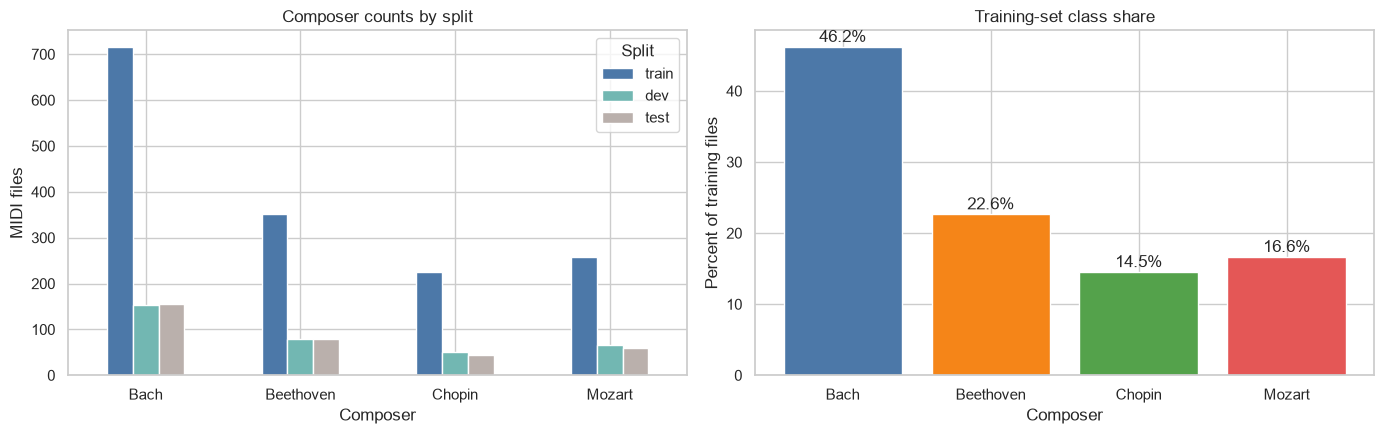

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
eda_split_summary.T.plot(kind="bar", ax=axes[0], color=["#4C78A8", "#72B7B2", "#BAB0AC"])
axes[0].set(title="Composer counts by split", xlabel="Composer", ylabel="MIDI files")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Split")

train_share = eda_train_df["composer"].value_counts(normalize=True).reindex(COMPOSER_ORDER) * 100
axes[1].bar(train_share.index, train_share.values, color=[COLORS[c] for c in train_share.index])
axes[1].set(title="Training-set class share", xlabel="Composer", ylabel="Percent of training files")
axes[1].tick_params(axis="x", rotation=0)
for index, value in enumerate(train_share.values):
    axes[1].text(index, value + 0.7, f"{value:.1f}%", ha="center")
fig.tight_layout()
plt.show()

### 7.4 Global timing and note-content distributions\n\nThese charts use the training split to show the distributions that the model will learn from.

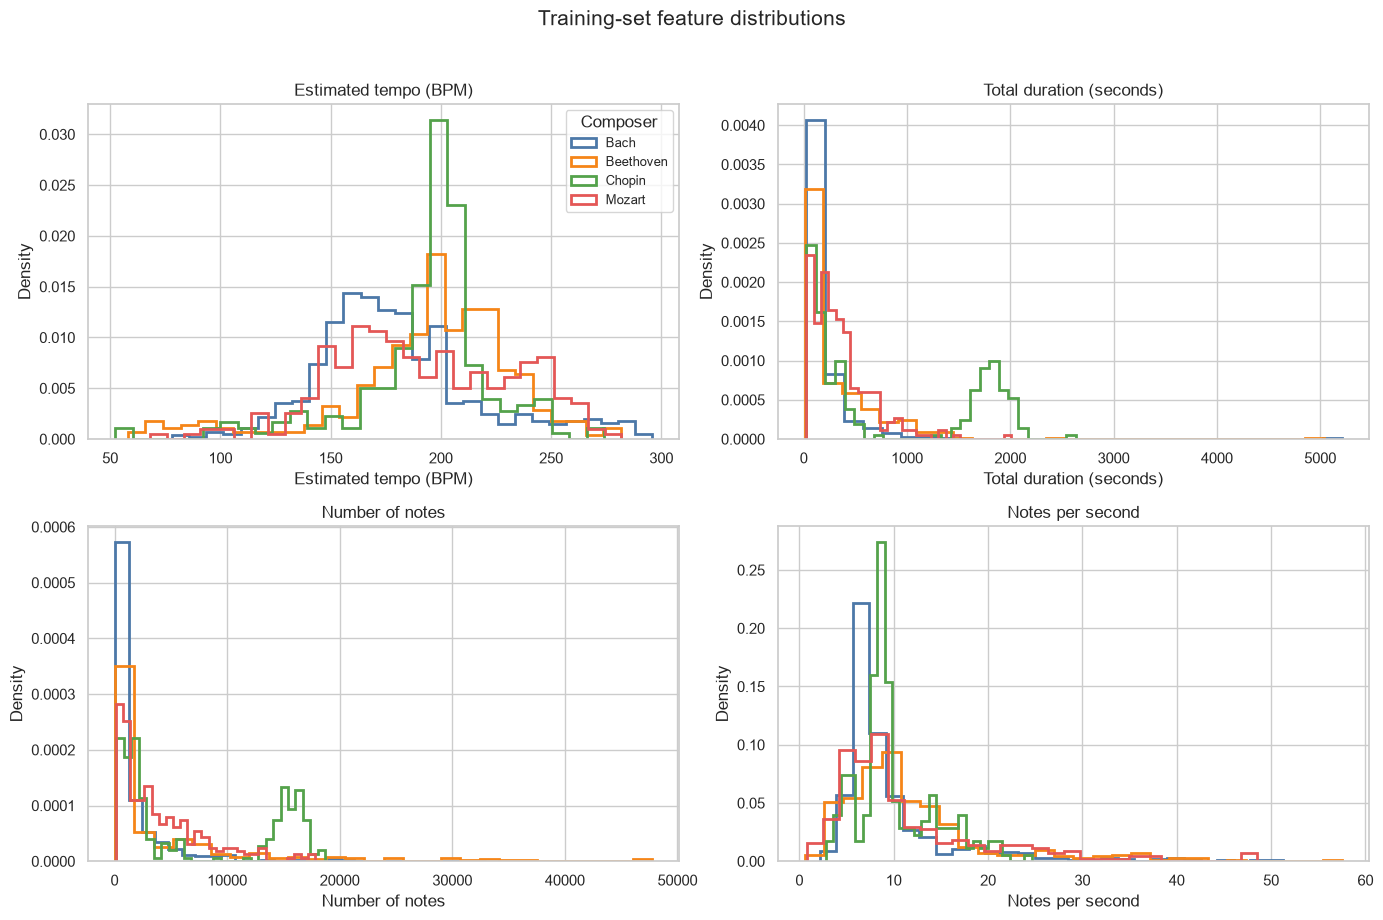

In [17]:
plot_features = [("tempo", "Estimated tempo (BPM)"), ("total_duration", "Total duration (seconds)"),
                  ("num_notes", "Number of notes"), ("note_density", "Notes per second")]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for axis, (feature, label) in zip(axes.flat, plot_features):
    for composer in COMPOSER_ORDER:
        values = eda_train_df.loc[eda_train_df["composer"] == composer, feature].dropna()
        axis.hist(values, bins=28, density=True, histtype="step", linewidth=2, label=composer, color=COLORS[composer])
    axis.set(title=label, xlabel=label, ylabel="Density")
axes[0, 0].legend(title="Composer", fontsize=9)
fig.suptitle("Training-set feature distributions", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

### 7.5 Composer comparison: pitch, rhythm, and texture

Each boxplot compares complete MIDI files in the training split. The center line is the median; the box contains the middle 50% of files; whiskers show the typical spread. Outliers are hidden to keep the central distributions readable.

**How to read the scales**: average pitch is the MIDI note number (middle C = 60); pitch standard deviation is in semitones; median note duration and mean onset interval are in seconds; polyphony is the number of simultaneously sounding notes.

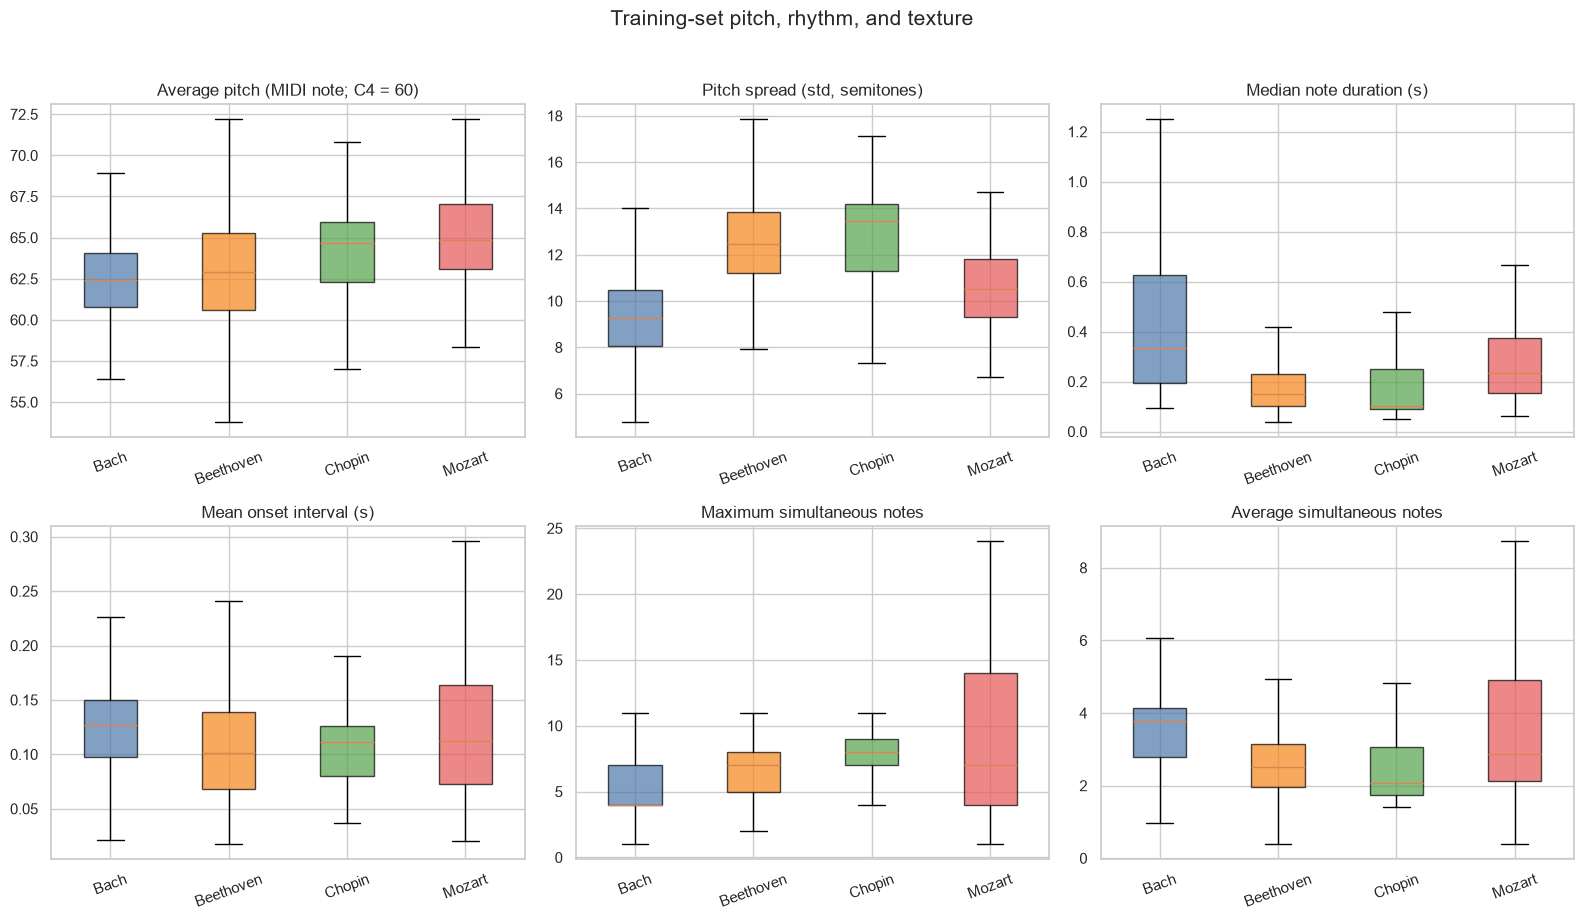

In [18]:
comparison_features = [("avg_pitch", "Average pitch (MIDI note; C4 = 60)"), ("pitch_std", "Pitch spread (std, semitones)"),
    ("duration_median", "Median note duration (s)"), ("onset_interval_mean", "Mean onset interval (s)"),
    ("max_polyphony", "Maximum simultaneous notes"), ("avg_polyphony", "Average simultaneous notes")]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for axis, (feature, label) in zip(axes.flat, comparison_features):
    values = [eda_train_df.loc[eda_train_df["composer"] == c, feature].dropna() for c in COMPOSER_ORDER]
    boxplot = axis.boxplot(values, tick_labels=COMPOSER_ORDER, patch_artist=True, showfliers=False)
    for patch, composer in zip(boxplot["boxes"], COMPOSER_ORDER):
        patch.set_facecolor(COLORS[composer])
        patch.set_alpha(0.7)
    axis.set_title(label)
    axis.tick_params(axis="x", rotation=20)
fig.suptitle("Training-set pitch, rhythm, and texture", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

### 7.6 Instrumentation and track structure\n\nGeneral MIDI program assignments are imperfect metadata, but they can describe the arrangement choices represented in the source files.

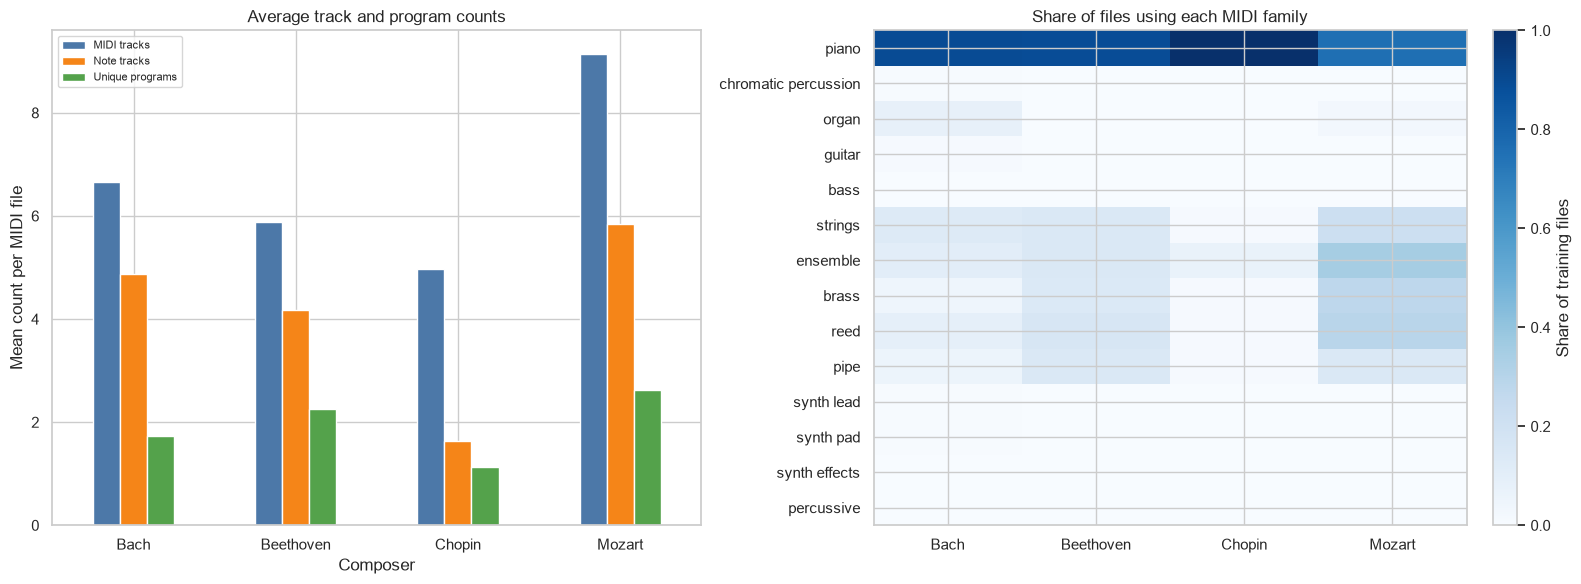

In [19]:
instrument_presence = (
    eda_train_df.groupby("composer", observed=True)[INSTRUMENT_COLUMNS]
            .apply(lambda group: (group > 0).mean())
            .reindex(COMPOSER_ORDER)
)
active_instrument_columns = instrument_presence.columns[instrument_presence.sum() > 0]
instrument_presence = instrument_presence[active_instrument_columns]
short_labels = [c.removeprefix("gm_").removesuffix("_track_count").replace("_", " ") for c in active_instrument_columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
track_summary = eda_train_df.groupby("composer", observed=True)[["num_midi_tracks", "num_note_tracks", "num_unique_programs"]].mean().reindex(COMPOSER_ORDER)
track_summary.plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set(title="Average track and program counts", xlabel="Composer", ylabel="Mean count per MIDI file")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(["MIDI tracks", "Note tracks", "Unique programs"], fontsize=8)

image = axes[1].imshow(instrument_presence.T, aspect="auto", cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("Share of files using each MIDI family")
axes[1].set_xticks(range(len(COMPOSER_ORDER)), COMPOSER_ORDER)
axes[1].set_yticks(range(len(short_labels)), short_labels)
colorbar = fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)
colorbar.set_label("Share of training files")
fig.tight_layout()
plt.show()

### 7.7 Composer feature profile\n\nThis heatmap standardizes selected training-set means across composers. It emphasizes relative stylistic differences rather than differences in feature units.

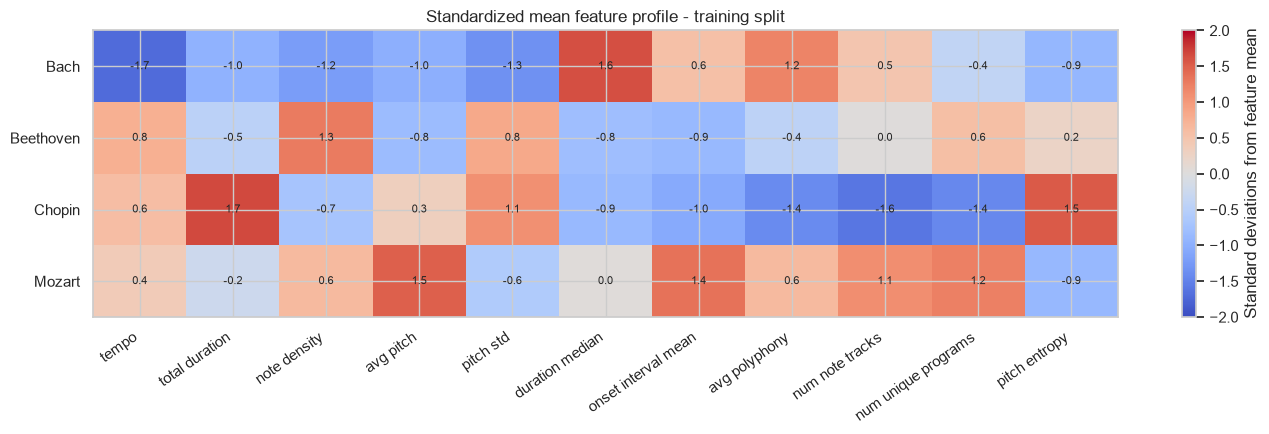

In [20]:
profile_features = ["tempo", "total_duration", "note_density", "avg_pitch", "pitch_std",
    "duration_median", "onset_interval_mean", "avg_polyphony", "num_note_tracks", "num_unique_programs", "pitch_entropy"]
composer_profile = eda_train_df.groupby("composer", observed=True)[profile_features].mean().reindex(COMPOSER_ORDER)
profile_zscores = (composer_profile - composer_profile.mean()) / composer_profile.std(ddof=0).replace(0, 1)

fig, axis = plt.subplots(figsize=(14, 4.5))
image = axis.imshow(profile_zscores, aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
axis.set_xticks(range(len(profile_features)), [f.replace("_", " ") for f in profile_features], rotation=35, ha="right")
axis.set_yticks(range(len(COMPOSER_ORDER)), COMPOSER_ORDER)
axis.set_title("Standardized mean feature profile - training split")
for row_index in range(len(COMPOSER_ORDER)):
    for column_index in range(len(profile_features)):
        axis.text(column_index, row_index, f"{profile_zscores.iloc[row_index, column_index]:.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=axis, label="Standard deviations from feature mean")
fig.tight_layout()
plt.show()

### 7.8 Feature redundancy and train-only separation ranking\n\nHighly correlated features may be redundant. The F statistic below is a univariate training-only screen: it identifies potentially useful features but does not replace cross-validated model evaluation.

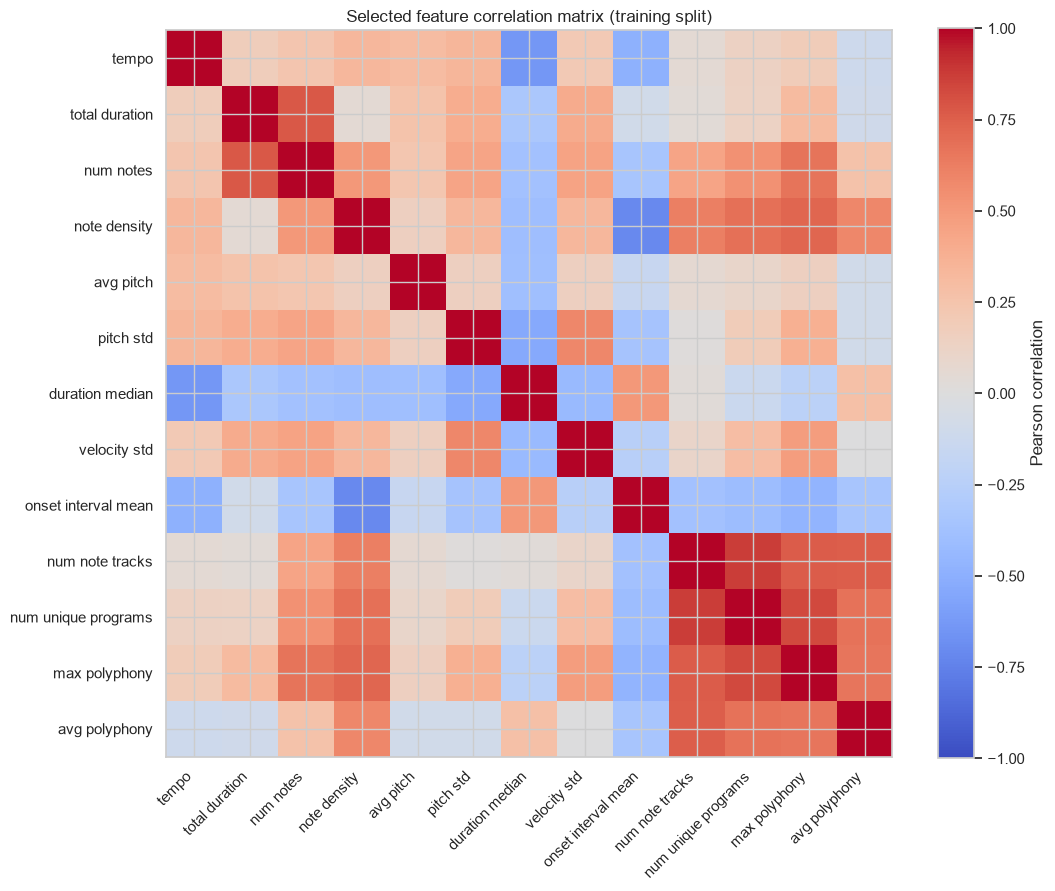

,feature,anova_f_score
0,velocity_range,604.919
1,velocity_std,510.069
2,range_normalized,433.414
3,pitch_range,423.055
4,pitch_std,270.229
5,avg_velocity,182.688
6,pitch_entropy,150.800
7,num_chords,147.822
8,total_duration,142.899
9,tempo_note_ratio,118.855


In [21]:
correlation_features = ["tempo", "total_duration", "num_notes", "note_density", "avg_pitch", "pitch_std",
    "duration_median", "velocity_std", "onset_interval_mean", "num_note_tracks", "num_unique_programs",
    "max_polyphony", "avg_polyphony"]
correlation = eda_train_df[correlation_features].corr()

fig, axis = plt.subplots(figsize=(11, 9))
image = axis.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
axis.set_xticks(range(len(correlation_features)), [f.replace("_", " ") for f in correlation_features], rotation=45, ha="right")
axis.set_yticks(range(len(correlation_features)), [f.replace("_", " ") for f in correlation_features])
axis.set_title("Selected feature correlation matrix (training split)")
fig.colorbar(image, ax=axis, label="Pearson correlation")
fig.tight_layout()
plt.show()


def anova_f_score(frame, feature, target="composer"):
    """Compute the one-way ANOVA F-statistic for a feature\'s separation across composer groups.

    A hand-rolled implementation (no scipy dependency) for a train-only univariate screen -
    identifies potentially useful features but does not replace cross-validated evaluation.

    Args:
        frame: DataFrame containing `feature` and `target` columns.
        feature: Numeric column name to score.
        target: Grouping column name (default "composer").

    Returns:
        The F-statistic (between-group variance / within-group variance), or NaN if undefined.
    """
    groups = [group[feature].dropna().to_numpy() for _, group in frame.groupby(target, observed=True)]
    groups = [group for group in groups if len(group) > 1]
    overall_mean = frame[feature].mean()
    between = sum(len(group) * (group.mean() - overall_mean) ** 2 for group in groups)
    within = sum(((group - group.mean()) ** 2).sum() for group in groups)
    degrees_between = len(groups) - 1
    degrees_within = sum(len(group) for group in groups) - len(groups)
    return (between / degrees_between) / (within / degrees_within) if within > 0 else np.nan


ranked_features = pd.DataFrame({
    "feature": MODEL_FEATURES,
    "anova_f_score": [anova_f_score(eda_train_df, feature) for feature in MODEL_FEATURES],
}).sort_values("anova_f_score", ascending=False)
display(ranked_features.head(15).reset_index(drop=True))

### 7.9 Before/after: did the imbalance correction work?\n\nComparing the original (pre-correction) training split against the combined (post-correction) one directly, using the same shipped CSVs.

,original_train,combined_train,delta
composer,,,
Bach,716,716,0
Beethoven,148,351,203
Chopin,95,225,130
Mozart,179,258,79


[SECTION 7] Bach:Chopin train ratio improved from 7.54:1 to 3.18:1


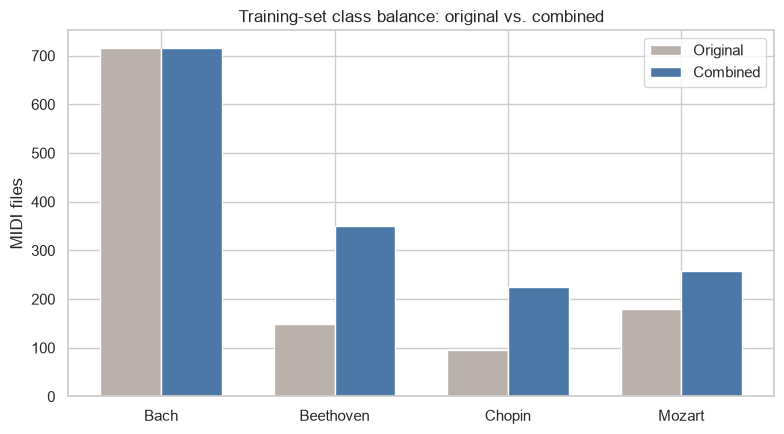

In [22]:
original_train_composer_counts = pd.read_csv(ORIGINAL_FEATURE_DIR / "train_features.csv")["composer"].value_counts()
combined_train_composer_counts = eda_train_df["composer"].value_counts()

before_after = pd.DataFrame({
    "original_train": original_train_composer_counts,
    "combined_train": combined_train_composer_counts,
}).reindex(COMPOSER_ORDER).fillna(0).astype(int)
before_after["delta"] = before_after["combined_train"] - before_after["original_train"]
display(before_after)

bach_chopin_before = before_after.loc["Bach", "original_train"] / before_after.loc["Chopin", "original_train"]
bach_chopin_after = before_after.loc["Bach", "combined_train"] / before_after.loc["Chopin", "combined_train"]
log("SECTION 7", f"Bach:Chopin train ratio improved from {bach_chopin_before:.2f}:1 to {bach_chopin_after:.2f}:1")

fig, axis = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(COMPOSER_ORDER))
width = 0.35
axis.bar(x - width / 2, before_after["original_train"], width, label="Original", color="#BAB0AC")
axis.bar(x + width / 2, before_after["combined_train"], width, label="Combined", color="#4C78A8")
axis.set_xticks(x, COMPOSER_ORDER)
axis.set_title("Training-set class balance: original vs. combined")
axis.set_ylabel("MIDI files")
axis.legend()
fig.tight_layout()
plt.show()

## 8. Preprocessing, Scaling & Split-Leakage Validation
**Original author: Beakal Zekaryas** &nbsp;|&nbsp; Source: `composer_model_project/MIDI_ Composer_Classification_CNN_LSTM_Models_Training_Evaluation.ipynb` &nbsp;|&nbsp; Treatment: **live**

Loads the pre-split, pre-assigned `combined_{train,dev,test}_features.csv` files as-is (no
re-splitting), validates schema/label consistency and confirms `relative_path` is disjoint
across splits (no leakage), drops constant training columns, and fits `StandardScaler`/
`LabelEncoder` on train only. The team's "dev" split is this notebook's validation split.

- **Loading pre-split feature CSVs.** The `combined_{train,dev,test}_features.csv` files are
  loaded as-is, without re-splitting, since the split assignment was already made
  deterministically in Section 4.
- **Schema, label, and leakage validation.** Column schemas and label sets are confirmed
  identical across the three splits, and the `relative_path` identifier sets are confirmed
  pairwise disjoint, ruling out the same MIDI file appearing in more than one split.
- **Constant-feature removal.** Of 60 numeric candidate features, two
  (`gm_ethnic_track_count`, `gm_sound_effects_track_count`) are constant on the training split
  and dropped, leaving 58 model features; this decision is learned from the training split only,
  to avoid leaking information from validation or test.
- **Scaling, encoding, and reshaping.** A `StandardScaler` and `LabelEncoder` are fit on the
  training split only and applied to all three splits; balanced class weights are computed from
  the training label distribution; and the scaled feature matrix is reshaped into a
  CNN-compatible form (features as an ordered one-dimensional sequence) and an LSTM-compatible
  form (a single timestep containing the full feature vector).

In [23]:
def find_csv(filename):
    """Locate a feature CSV by name, searching common candidate locations.

    Args:
        filename: CSV filename to find, e.g. "combined_train_features.csv".

    Returns:
        Resolved Path to the first matching file found.

    Raises:
        FileNotFoundError: If no candidate path or recursive search match exists.
    """
    direct_candidates = [
        PROJECT_ROOT / filename,
        PROJECT_ROOT / "data" / filename,
        PROJECT_ROOT / "data" / "features" / filename,
        FEATURE_DIR / filename,
    ]
    direct_candidates.extend(PROJECT_ROOT.rglob(filename))
    match = next((path for path in direct_candidates if path.exists()), None)
    if match is None:
        raise FileNotFoundError(f"{filename} was not found under {PROJECT_ROOT} or {FEATURE_DIR}")
    return match

TRAIN_PATH = find_csv("combined_train_features.csv")
DEV_PATH = find_csv("combined_dev_features.csv")
TEST_PATH = find_csv("combined_test_features.csv")

train_df = pd.read_csv(TRAIN_PATH)
dev_df = pd.read_csv(DEV_PATH)
test_df = pd.read_csv(TEST_PATH)

log("SECTION 8", f"Training: {train_df.shape} {TRAIN_PATH}")
log("SECTION 8", f"Development: {dev_df.shape} {DEV_PATH}")
log("SECTION 8", f"Held-out test: {test_df.shape} {TEST_PATH}")

[SECTION 8] Training: (1550, 63) C:\mycode\msaai511-finalproject\MIDI-Composer-Classification\data\features\combined_train_features.csv
[SECTION 8] Development: (351, 63) C:\mycode\msaai511-finalproject\MIDI-Composer-Classification\data\features\combined_dev_features.csv
[SECTION 8] Held-out test: (338, 63) C:\mycode\msaai511-finalproject\MIDI-Composer-Classification\data\features\combined_test_features.csv


In [24]:
"""Schema/label consistency and split-leakage validation (no NaNs, identical columns/labels
across splits, and no MIDI file appears in more than one split)."""
expected_shape_columns = list(train_df.columns)
assert expected_shape_columns == list(dev_df.columns) == list(test_df.columns)
assert not train_df.isna().any().any()
assert not dev_df.isna().any().any()
assert not test_df.isna().any().any()

expected_labels = set(train_df["composer"])
assert expected_labels == set(dev_df["composer"]) == set(test_df["composer"])

# Confirming the supplied splits do not contain the same MIDI paths (leakage check).
train_paths = set(train_df["relative_path"])
dev_paths = set(dev_df["relative_path"])
test_paths = set(test_df["relative_path"])
assert train_paths.isdisjoint(dev_paths)
assert train_paths.isdisjoint(test_paths)
assert dev_paths.isdisjoint(test_paths)
log("SECTION 8", "No cross-split leakage: relative_path sets are pairwise disjoint")

model_split_summary = pd.DataFrame({
    "Train": train_df["composer"].value_counts(),
    "Development": dev_df["composer"].value_counts(),
    "Held-out Test": test_df["composer"].value_counts(),
}).fillna(0).astype(int)
display(model_split_summary)

[SECTION 8] No cross-split leakage: relative_path sets are pairwise disjoint


,Train,Development,Held-out Test
composer,,,
Bach,716,153,155
Beethoven,351,80,78
Mozart,258,67,60
Chopin,225,51,45


In [25]:
TARGET = "composer"
IDENTIFIER_COLUMNS = ["filename", "relative_path"]
excluded_columns = [TARGET] + IDENTIFIER_COLUMNS

candidate_features = [c for c in train_df.columns if c not in excluded_columns]
non_numeric = [c for c in candidate_features if not pd.api.types.is_numeric_dtype(train_df[c])]
if non_numeric:
    raise TypeError(f"Unexpected nonnumeric predictors: {non_numeric}")

# Learn removal decisions from training only.
constant_features = [c for c in candidate_features if train_df[c].nunique(dropna=False) <= 1]
feature_names = [c for c in candidate_features if c not in constant_features]

log("SECTION 8", f"Numeric candidate features: {len(candidate_features)}")
log("SECTION 8", f"Constant training features removed: {constant_features}")
log("SECTION 8", f"Final model features: {len(feature_names)}")

[SECTION 8] Numeric candidate features: 60
[SECTION 8] Constant training features removed: ['gm_ethnic_track_count', 'gm_sound_effects_track_count']
[SECTION 8] Final model features: 58


In [26]:
"""Fit preprocessing objects on training data only; reshape for both architectures.

Note: every CSV row is one composition-level observation, not a temporal sequence - the LSTM
sees a single timestep containing the complete feature vector (this is a gated composition-level
classifier, not a model of note-to-note temporal structure)."""
scaler = StandardScaler()
X_train_2d = scaler.fit_transform(train_df[feature_names]).astype("float32")
X_dev_2d = scaler.transform(dev_df[feature_names]).astype("float32")
X_test_2d = scaler.transform(test_df[feature_names]).astype("float32")

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(train_df[TARGET])
y_dev = label_encoder.transform(dev_df[TARGET])
y_test = label_encoder.transform(test_df[TARGET])

class_ids = np.arange(len(label_encoder.classes_))
weights = compute_class_weight(class_weight="balanced", classes=class_ids, y=y_train)
class_weights = dict(zip(class_ids, weights))

# CNN convolves across the ordered feature vector.
X_train_cnn = X_train_2d[..., np.newaxis]
X_dev_cnn = X_dev_2d[..., np.newaxis]
X_test_cnn = X_test_2d[..., np.newaxis]

# LSTM: single timestep containing the full feature vector.
X_train_lstm = X_train_2d[:, np.newaxis, :]
X_dev_lstm = X_dev_2d[:, np.newaxis, :]
X_test_lstm = X_test_2d[:, np.newaxis, :]

log("SECTION 8", f"Classes: {list(label_encoder.classes_)}")
log("SECTION 8", f"CNN input: {X_train_cnn.shape} | LSTM input: {X_train_lstm.shape}")

[SECTION 8] Classes: ['Bach', 'Beethoven', 'Chopin', 'Mozart']


[SECTION 8] CNN input: (1550, 58, 1) | LSTM input: (1550, 1, 58)


## 9. Model Building

The CNN learns local interactions among adjacent, logically ordered MIDI descriptors. The LSTM
is a gated composition-level classifier — a true temporal LSTM over individual notes would
require event-sequence files rather than one aggregate row per composition (see Section 17).

*(Renamed `build_cnn`/`build_lstm` &rarr; `build_baseline_cnn`/`build_baseline_lstm` to avoid a
naming collision with Section 13's tunable `build_tuned_cnn(hp)`/`build_tuned_lstm(hp)`, which
share the same architecture family but a different function signature.)*

- **Baseline CNN architecture.** A 1D convolutional network (two `Conv1D` layers with max
  pooling, followed by dense and dropout layers) is defined to learn local interactions among
  adjacent, logically ordered MIDI descriptors, compiled with the Adam optimizer and sparse
  categorical cross-entropy loss.
- **Baseline LSTM architecture.** A single-layer LSTM classifier is defined over the
  single-timestep feature representation produced in Section 8, with dropout and a dense hidden
  layer preceding the softmax output. Both models are compiled and their parameter counts
  summarized (31,524 for the CNN, 12,836 for the LSTM).

In [27]:
NUM_CLASSES = len(label_encoder.classes_)

def build_baseline_cnn():
    """Build and compile the baseline 1D CNN classifier.

    Architecture: Conv1D(16, k=5, L2=1e-4) -> MaxPool -> Conv1D(32, k=3) -> Flatten ->
    Dense(32) -> Dropout(0.3) -> Dense(4, softmax).

    Returns:
        A compiled tf.keras.Sequential model.
    """
    model = Sequential([
        Input(shape=X_train_cnn.shape[1:]),
        Conv1D(16, kernel_size=5, padding="same", activation="relu", kernel_regularizer=l2(1e-4)),
        MaxPooling1D(pool_size=2),
        Conv1D(32, kernel_size=3, padding="same", activation="relu"),
        Flatten(),
        Dense(32, activation="relu"),
        Dropout(0.30),
        Dense(NUM_CLASSES, activation="softmax"),
    ], name="composer_cnn")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


def build_baseline_lstm():
    """Build and compile the baseline LSTM classifier.

    Architecture: LSTM(32) -> Dropout(0.3) -> Dense(32) -> Dropout(0.2) -> Dense(4, softmax),
    over a single timestep containing the full feature vector.

    Returns:
        A compiled tf.keras.Model.
    """
    inputs = Input(shape=X_train_lstm.shape[1:])
    x = LSTM(32)(inputs)
    x = Dropout(0.30)(x)
    x = Dense(32, activation="relu")(x)
    x = Dropout(0.20)(x)
    outputs = Dense(NUM_CLASSES, activation="softmax")(x)
    model = Model(inputs, outputs, name="composer_lstm")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

cnn_model = build_baseline_cnn()
lstm_model = build_baseline_lstm()

cnn_model.summary()
lstm_model.summary()

Model: "composer_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 58, 16)         │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 29, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 29, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 928)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        29,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,524 (123.14 KB)

 Trainable params: 31,524 (123.14 KB)

 Non-trainable params: 0 (0.00 B)

Model: "composer_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1, 58)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │        11,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,836 (50.14 KB)

 Trainable params: 12,836 (50.14 KB)

 Non-trainable params: 0 (0.00 B)

## 10. Model Training

Full-batch training (one gradient step per epoch) for 60 epochs, with `EarlyStopping`,
`ReduceLROnPlateau`, and `ModelCheckpoint`, using `class_weight='balanced'` identically for both
models. `ARTIFACT_DIR` is repointed under this notebook's own output folder so it never collides
with the standalone evaluation notebooks' saved artifacts.

- **Training configuration.** Both models are trained for up to 60 epochs using full-batch
  gradient descent (one step per epoch), with early stopping on validation loss (patience 10),
  learning-rate reduction on plateau, and checkpointing of the best weights; the fitted scaler,
  label encoder, and feature-name list are saved for downstream reuse.
- **Model fitting.** The CNN and LSTM are each trained with `class_weight='balanced'` applied
  identically, using the training split for gradient updates and the development split for
  early-stopping and learning-rate decisions.

In [28]:
EPOCHS = 60
BATCH_SIZE = len(X_train_2d)  # Full-batch training matches the verified reference run.

def callbacks_for(model_name):
    """Build the standard callback set (early stopping, LR reduction, checkpointing) for a model.

    Args:
        model_name: Short name used for the checkpoint filename, e.g. "cnn" or "lstm".

    Returns:
        List of Keras callbacks.
    """
    return [
        EarlyStopping(monitor="val_loss", patience=10, min_delta=1e-4, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        ModelCheckpoint(ARTIFACT_DIR / f"{model_name}_best.keras", monitor="val_loss", save_best_only=True),
    ]

joblib.dump(scaler, ARTIFACT_DIR / "standard_scaler.joblib")
joblib.dump(label_encoder, ARTIFACT_DIR / "label_encoder.joblib")
pd.Series(feature_names, name="feature").to_csv(ARTIFACT_DIR / "model_features.csv", index=False)

In [29]:
cnn_history = cnn_model.fit(
    X_train_cnn, y_train, validation_data=(X_dev_cnn, y_dev),
    epochs=EPOCHS, batch_size=BATCH_SIZE, class_weight=class_weights,
    callbacks=callbacks_for("cnn"), verbose=1,
)

Epoch 1/60



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3877 - loss: 1.4147


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3877 - loss: 1.4147 - val_accuracy: 0.2621 - val_loss: 1.3079 - learning_rate: 0.0050


Epoch 2/60



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.2697 - loss: 1.3060

...

Epoch 60/60



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9452 - loss: 0.1452


Epoch 60: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9452 - loss: 0.1452 - val_accuracy: 0.9060 - val_loss: 0.3358 - learning_rate: 0.0050


Restoring model weights from the end of the best epoch: 55.


In [30]:
lstm_history = lstm_model.fit(
    X_train_lstm, y_train, validation_data=(X_dev_lstm, y_dev),
    epochs=EPOCHS, batch_size=BATCH_SIZE, class_weight=class_weights,
    callbacks=callbacks_for("lstm"), verbose=1,
)

Epoch 1/60



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.1761 - loss: 1.4025


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.1761 - loss: 1.4025 - val_accuracy: 0.2536 - val_loss: 1.3984 - learning_rate: 0.0030


Epoch 2/60



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.2013 - loss: 1.3771

...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.8465 - loss: 0.4554 - val_accuracy: 0.8519 - val_loss: 0.4140 - learning_rate: 0.0030


Epoch 60/60



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.8555 - loss: 0.4243


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.8555 - loss: 0.4243 - val_accuracy: 0.8519 - val_loss: 0.4096 - learning_rate: 0.0030


Restoring model weights from the end of the best epoch: 60.


## 11. Held-Out Test Evaluation


The test set is used only here, after preprocessing and model selection are complete. Macro
metrics give all four composers equal importance, correcting for class imbalance in the report
(unlike raw accuracy).

- **Held-out test scoring.** Each trained model is scored once on the test set, producing
  accuracy, macro-averaged precision/recall/F1, weighted F1, and a full per-composer
  classification report for both the CNN and the LSTM.
- **Confusion matrices.** Raw-count and recall-normalized confusion matrices are plotted for
  both models on the test set, showing per-composer error patterns beyond a single aggregate
  score. *Flagged for review: the raw-count panels are recomputed again, alongside the
  validation split, in Section 12 (cell 58); only the recall-normalized view here is not
  reproduced elsewhere.*
- **Training curves.** Training and validation loss/accuracy curves are plotted per model
  directly from the fit history. *Flagged for review: Section 12 (cell 59) reproduces the same
  curves with the held-out test score overlaid as a reference line, making this panel a strict
  subset of the later one and a candidate for removal.*

In [31]:
def evaluate_model(model, X_test, model_name):
    """Score a trained model on the held-out test set.

    Args:
        model: A trained, compiled Keras model.
        X_test: Test features, already reshaped for this model\'s input.
        model_name: Label used in the returned metrics dict.

    Returns:
        Tuple of (metrics dict, per-class classification_report DataFrame, predicted class
        indices, predicted class probabilities).
    """
    probabilities = model.predict(X_test, verbose=0)
    predictions = probabilities.argmax(axis=1)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_test, predictions, average="macro", zero_division=0)
    _, _, weighted_f1, _ = precision_recall_fscore_support(
        y_test, predictions, average="weighted", zero_division=0)
    metrics = {"Model": model_name, "Accuracy": accuracy_score(y_test, predictions),
               "Macro Precision": macro_precision, "Macro Recall": macro_recall,
               "Macro F1": macro_f1, "Weighted F1": weighted_f1}
    report = pd.DataFrame(classification_report(
        y_test, predictions, labels=class_ids, target_names=label_encoder.classes_,
        output_dict=True, zero_division=0)).T
    return metrics, report, predictions, probabilities

cnn_metrics, cnn_report, cnn_predictions, cnn_probabilities = evaluate_model(cnn_model, X_test_cnn, "CNN")
lstm_metrics, lstm_report, lstm_predictions, lstm_probabilities = evaluate_model(lstm_model, X_test_lstm, "LSTM")

metrics_df = pd.DataFrame([cnn_metrics, lstm_metrics]).sort_values("Macro F1", ascending=False)
display(metrics_df.style.format({"Accuracy": "{:.3f}", "Macro Precision": "{:.3f}",
    "Macro Recall": "{:.3f}", "Macro F1": "{:.3f}", "Weighted F1": "{:.3f}"}))
print("CNN per-composer report")
display(cnn_report.round(3))
print("LSTM per-composer report")
display(lstm_report.round(3))

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,CNN,0.896,0.871,0.880,0.875,0.897
1,LSTM,0.834,0.806,0.802,0.802,0.834


CNN per-composer report


,precision,recall,f1-score,support
Bach,0.967,0.935,0.951,155.000
Beethoven,0.883,0.872,0.877,78.000
Chopin,0.844,0.844,0.844,45.000
Mozart,0.788,0.867,0.825,60.000
accuracy,0.896,0.896,0.896,0.896
macro avg,0.871,0.880,0.875,338.000
weighted avg,0.899,0.896,0.897,338.000


LSTM per-composer report


,precision,recall,f1-score,support
Bach,0.905,0.923,0.914,155.000
Beethoven,0.851,0.731,0.786,78.000
Chopin,0.773,0.756,0.764,45.000
Mozart,0.696,0.800,0.744,60.000
accuracy,0.834,0.834,0.834,0.834
macro avg,0.806,0.802,0.802,338.000
weighted avg,0.838,0.834,0.834,338.000


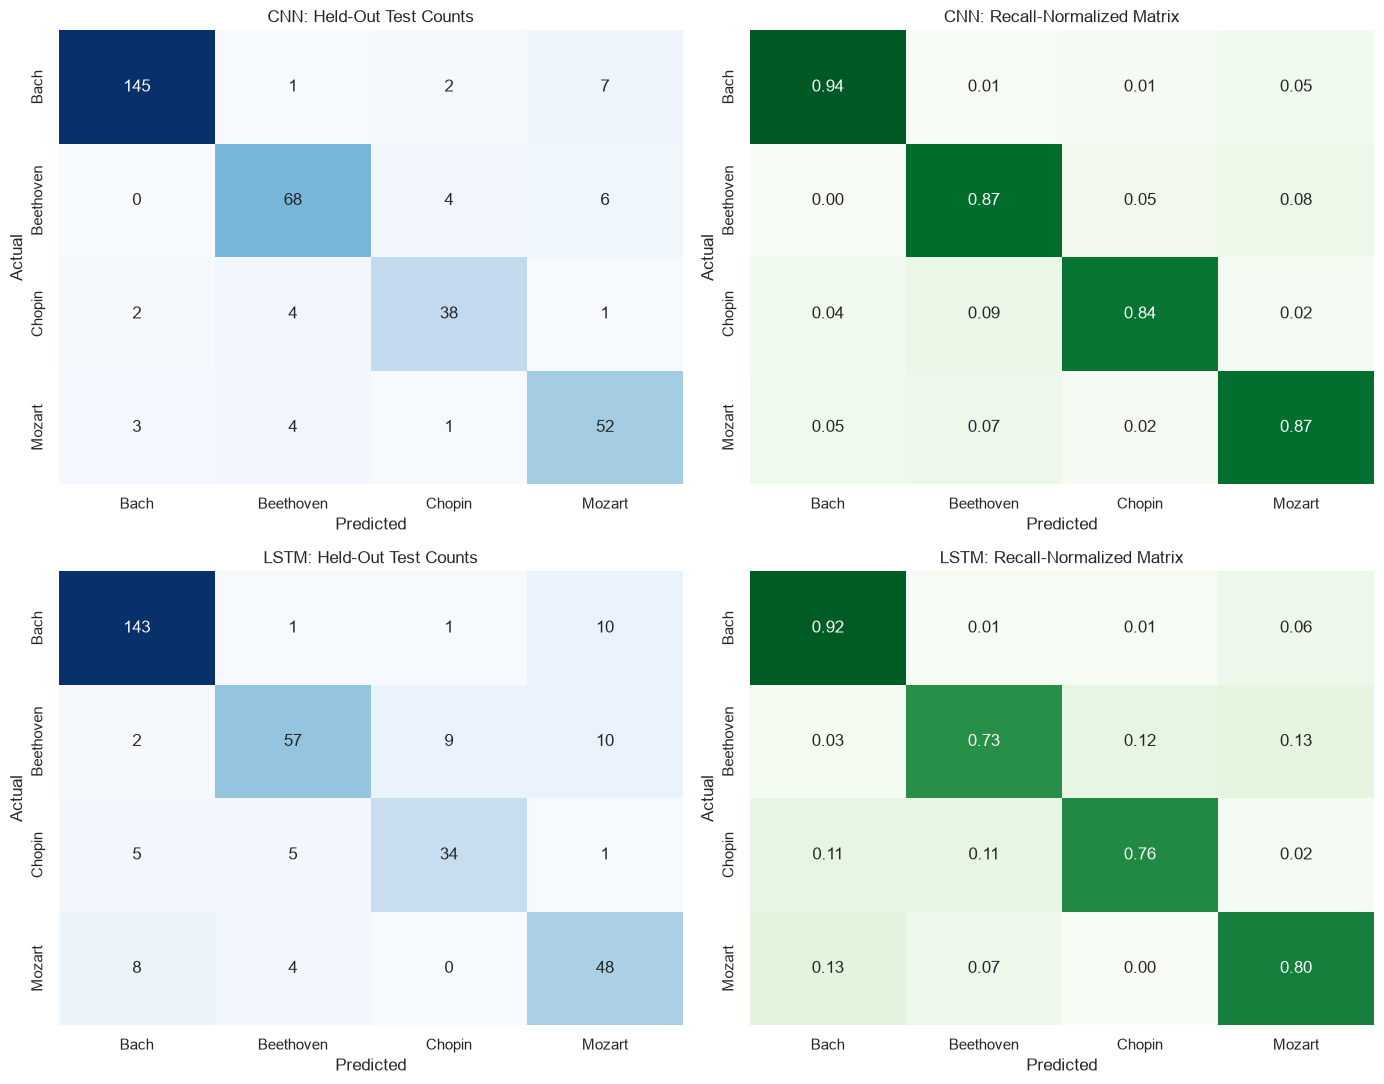

In [32]:
metrics_df.to_csv(ARTIFACT_DIR / "held_out_test_metrics.csv", index=False)

prediction_df = pd.DataFrame({
    "filename": test_df["filename"].values, "relative_path": test_df["relative_path"].values,
    "actual_composer": label_encoder.inverse_transform(y_test),
    "cnn_prediction": label_encoder.inverse_transform(cnn_predictions), "cnn_confidence": cnn_probabilities.max(axis=1),
    "lstm_prediction": label_encoder.inverse_transform(lstm_predictions), "lstm_confidence": lstm_probabilities.max(axis=1),
})
prediction_df.to_csv(ARTIFACT_DIR / "held_out_test_predictions.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for row, (name, predictions) in enumerate({"CNN": cnn_predictions, "LSTM": lstm_predictions}.items()):
    raw = confusion_matrix(y_test, predictions, labels=class_ids)
    normalized = confusion_matrix(y_test, predictions, labels=class_ids, normalize="true")
    sns.heatmap(raw, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[row, 0])
    axes[row, 0].set(title=f"{name}: Held-Out Test Counts", xlabel="Predicted", ylabel="Actual")
    sns.heatmap(normalized, annot=True, fmt=".2f", cmap="Greens", vmin=0, vmax=1, cbar=False,
        xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=axes[row, 1])
    axes[row, 1].set(title=f"{name}: Recall-Normalized Matrix", xlabel="Predicted", ylabel="Actual")
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "confusion_matrices.png", dpi=150)
plt.show()

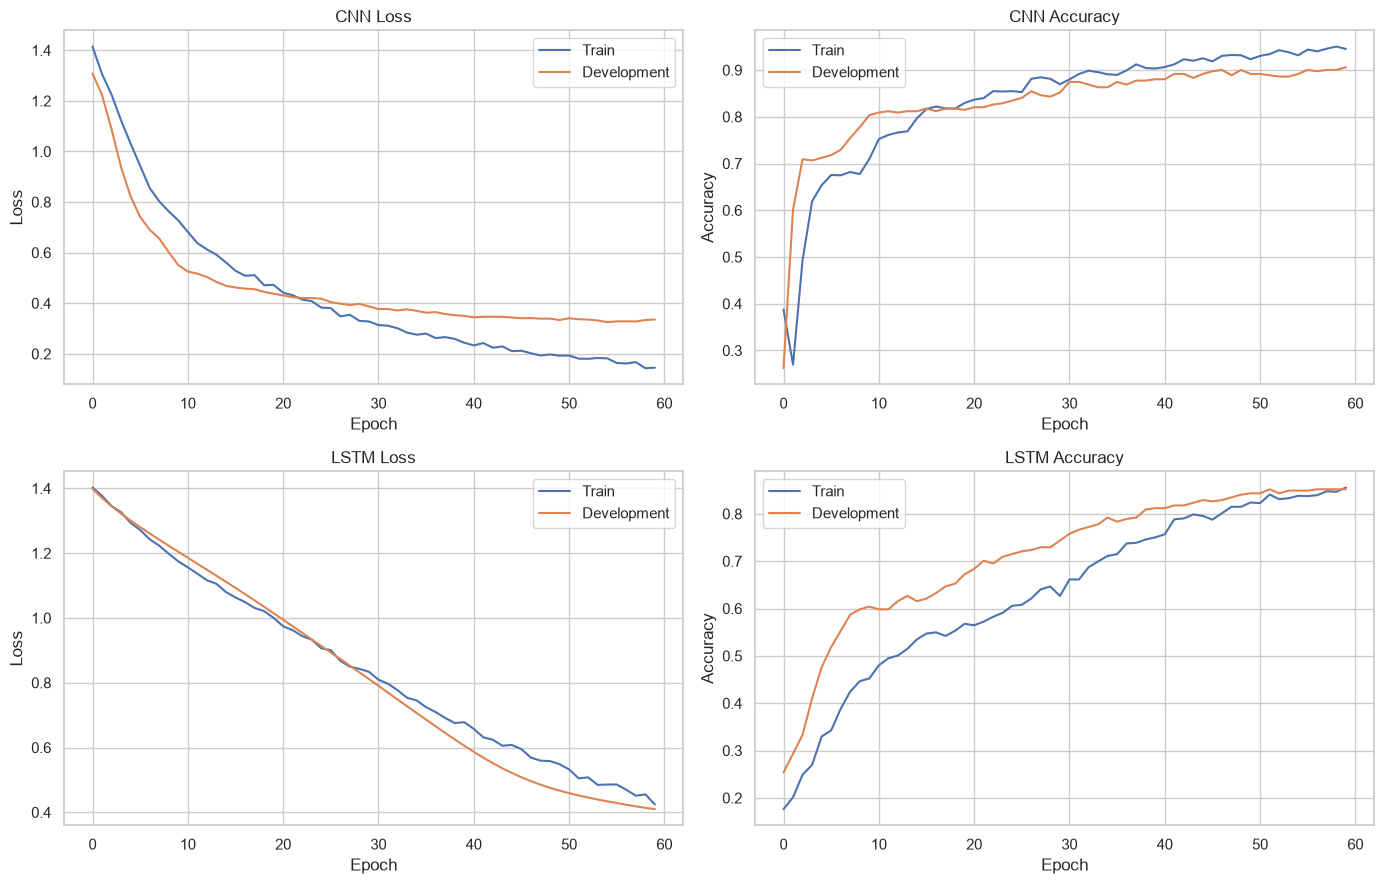

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for row, (name, history) in enumerate({"CNN": cnn_history, "LSTM": lstm_history}.items()):
    axes[row, 0].plot(history.history["loss"], label="Train")
    axes[row, 0].plot(history.history["val_loss"], label="Development")
    axes[row, 0].set(title=f"{name} Loss", xlabel="Epoch", ylabel="Loss")
    axes[row, 0].legend()
    axes[row, 1].plot(history.history["accuracy"], label="Train")
    axes[row, 1].plot(history.history["val_accuracy"], label="Development")
    axes[row, 1].set(title=f"{name} Accuracy", xlabel="Epoch", ylabel="Accuracy")
    axes[row, 1].legend()
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "training_curves.png", dpi=150)
plt.show()

### 11.5 Observations

Held-out test results: **CNN accuracy 0.896, macro F1 0.875; LSTM accuracy 0.834,
macro F1 0.802** — CNN is the stronger model. Per-class F1 (CNN test): Bach 0.95, Beethoven 0.88,
Chopin 0.85, Mozart 0.83 (LSTM: Bach 0.91, Beethoven 0.79, Chopin 0.76, Mozart 0.74). Both models
follow the same pattern. Bach (unchanged training count) is easiest, Mozart is hardest for both.

## 12. Evaluation: Test vs. Validation


Extends Section 11's test-only evaluation with: classification report and confusion matrices on
**both** test and validation, loss/accuracy curves with the final test score overlaid, multiclass
ROC curves, permutation feature importance, and SHAP — all computed on the **same** `cnn_model`/
`lstm_model` objects trained in Section 10 (no retraining here, so there is exactly one "CNN test
accuracy" number in this notebook, not two). The aliasing cell below only maps Section 8-11's
variable names onto the names this section's code was originally written against.

- **Variable aliasing.** Section 8-11's variable names are mapped onto the names this section's
  original code expects (e.g., `X_val_cnn` aliasing `X_dev_cnn`), so the ported code runs
  unmodified; no retraining occurs here — the same `cnn_model`/`lstm_model` trained in Section 10
  are reused throughout. *Flagged for review: this eleven-name aliasing layer exists only to
  avoid renaming variables in the ported code and could be removed by adopting the `val_*` names
  directly upstream.*
- **Four-way evaluation.** Both models are scored on both the test and validation splits (four
  combinations total), each producing a classification report and summary metrics. *Flagged for
  review: the CNN-test and LSTM-test entries recompute results numerically identical to
  Section 11's evaluation of the same trained models on the same test set; the two are not
  expected to disagree, since no retraining happens between them, but the inference and metric
  computation are genuinely performed twice.*
- **Confusion matrices, test and validation.** A 2x2 grid of confusion matrices covers both
  models on both splits, superseding the test-only pair already drawn in Section 11.
- **Loss/accuracy curves with test overlay.** The Section 11 training curves are redrawn with
  the final test loss/accuracy added as a reference line.
- **ROC curves and AUC.** One-vs-rest ROC curves and per-class AUC are plotted and tabulated for
  all four (model, split) combinations, via a `plot_roc` helper reused again in Section 13 for
  the tuned models.
- **Permutation feature importance.** Per-feature accuracy drop under column-wise shuffling is
  computed for all four combinations, ranking which of the 58 features each model relies on
  most.
- **SHAP explanation.** A model-agnostic `KernelExplainer` (rather than the faster
  `DeepExplainer`, which was found to corrupt TensorFlow's gradient registry and interfere with
  Section 13's later Keras Tuner search when both ran in the same kernel) is used to compute
  SHAP values on a 100-row background / 100-row explanation sample, producing per-class summary
  plots for both models.

In [34]:
"""Alias Section 8-11\'s (Beakal\'s) variable names onto the names this section\'s original
code expects, so the code below is otherwise unchanged from Composer_Classification_Evaluation.ipynb.
No retraining happens here - X_val_*/y_val are the same "dev" split already used for model
selection in Section 10."""
X_val_cnn, X_val_lstm, y_val = X_dev_cnn, X_dev_lstm, y_dev
X_val_2d = X_dev_2d
class_names = label_encoder.classes_
classes_arr = class_ids
n_classes = NUM_CLASSES
n_features = len(feature_names)
feature_columns = feature_names
X_test_2d_alias = X_test_2d  # already named X_test_2d upstream; kept for clarity

cnn_reshape = lambda arr: arr[..., np.newaxis]
lstm_reshape = lambda arr: arr[:, np.newaxis, :]

log("SECTION 12", "Aliased dev->val naming; reusing cnn_model/lstm_model trained in Section 10")

[SECTION 12] Aliased dev->val naming; reusing cnn_model/lstm_model trained in Section 10


In [35]:
def evaluate_split(name, model, X, y_true):
    """Score a model on one data split and print its classification report.

    Args:
        name: Label for this (model, split) combination, e.g. "CNN-test".
        model: Trained Keras model.
        X: Feature array, already reshaped for this model.
        y_true: True integer class labels.

    Returns:
        Tuple of (metrics dict, predicted labels, predicted probabilities).
    """
    probabilities = model.predict(X, verbose=0)
    predictions = probabilities.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, predictions, average="macro", zero_division=0)
    result = {"model_split": name, "accuracy": accuracy_score(y_true, predictions),
              "macro_precision": precision, "macro_recall": recall, "macro_f1": f1}
    print(f"\n{name}")
    print(classification_report(y_true, predictions, target_names=class_names, zero_division=0))
    return result, predictions, probabilities

eval_specs = [("CNN-test", cnn_model, X_test_cnn, y_test), ("CNN-val", cnn_model, X_val_cnn, y_val),
              ("LSTM-test", lstm_model, X_test_lstm, y_test), ("LSTM-val", lstm_model, X_val_lstm, y_val)]

eval_results = {}
for name, model, X, y_true in eval_specs:
    result, predictions, probabilities = evaluate_split(name, model, X, y_true)
    eval_results[name] = {"result": result, "predictions": predictions, "probabilities": probabilities, "y_true": y_true}

results_df = pd.DataFrame([v["result"] for v in eval_results.values()]).set_index("model_split")
results_df.to_csv(OUTPUT_DIR / "test_vs_val_metrics.csv")
display(results_df.style.format("{:.3f}"))


CNN-test
              precision    recall  f1-score   support

        Bach       0.97      0.94      0.95       155
   Beethoven       0.88      0.87      0.88        78
      Chopin       0.84      0.84      0.84        45
      Mozart       0.79      0.87      0.83        60

    accuracy                           0.90       338
   macro avg       0.87      0.88      0.87       338
weighted avg       0.90      0.90      0.90       338


CNN-val
              precision    recall  f1-score   support

        Bach       0.95      0.95      0.95       153
   Beethoven       0.86      0.85      0.86        80
      Chopin       0.92      0.88      0.90        51
      Mozart       0.77      0.81      0.79        67

    accuracy                           0.89       351
   macro avg       0.88      0.87      0.87       351
weighted avg       0.89      0.89      0.89       351




LSTM-test
              precision    recall  f1-score   support

        Bach       0.91      0.92      0.91       155
   Beethoven       0.85      0.73      0.79        78
      Chopin       0.77      0.76      0.76        45
      Mozart       0.70      0.80      0.74        60

    accuracy                           0.83       338
   macro avg       0.81      0.80      0.80       338
weighted avg       0.84      0.83      0.83       338




LSTM-val
              precision    recall  f1-score   support

        Bach       0.91      0.95      0.93       153
   Beethoven       0.84      0.74      0.79        80
      Chopin       0.85      0.86      0.85        51
      Mozart       0.74      0.76      0.75        67

    accuracy                           0.85       351
   macro avg       0.83      0.83      0.83       351
weighted avg       0.85      0.85      0.85       351



,accuracy,macro_precision,macro_recall,macro_f1
model_split,,,,
CNN-test,0.896,0.871,0.880,0.875
CNN-val,0.892,0.876,0.873,0.874
LSTM-test,0.834,0.806,0.802,0.802
LSTM-val,0.852,0.834,0.827,0.829


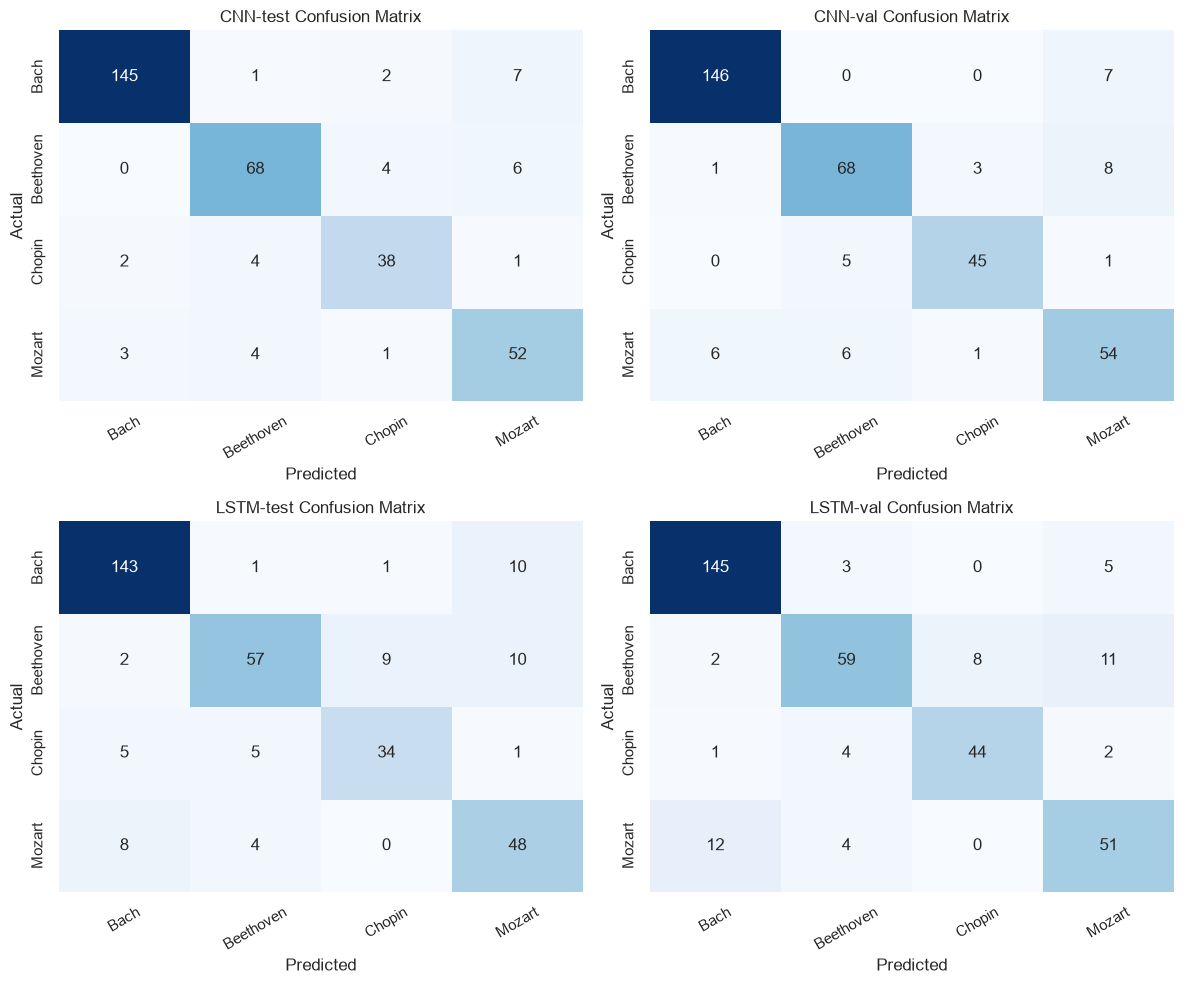

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
layout = [("CNN-test", axes[0, 0]), ("CNN-val", axes[0, 1]), ("LSTM-test", axes[1, 0]), ("LSTM-val", axes[1, 1])]
for name, ax in layout:
    entry = eval_results[name]
    cm = confusion_matrix(entry["y_true"], entry["predictions"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set(title=f"{name} Confusion Matrix", xlabel="Predicted", ylabel="Actual")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrices_test_vs_val.png", dpi=150)
plt.show()

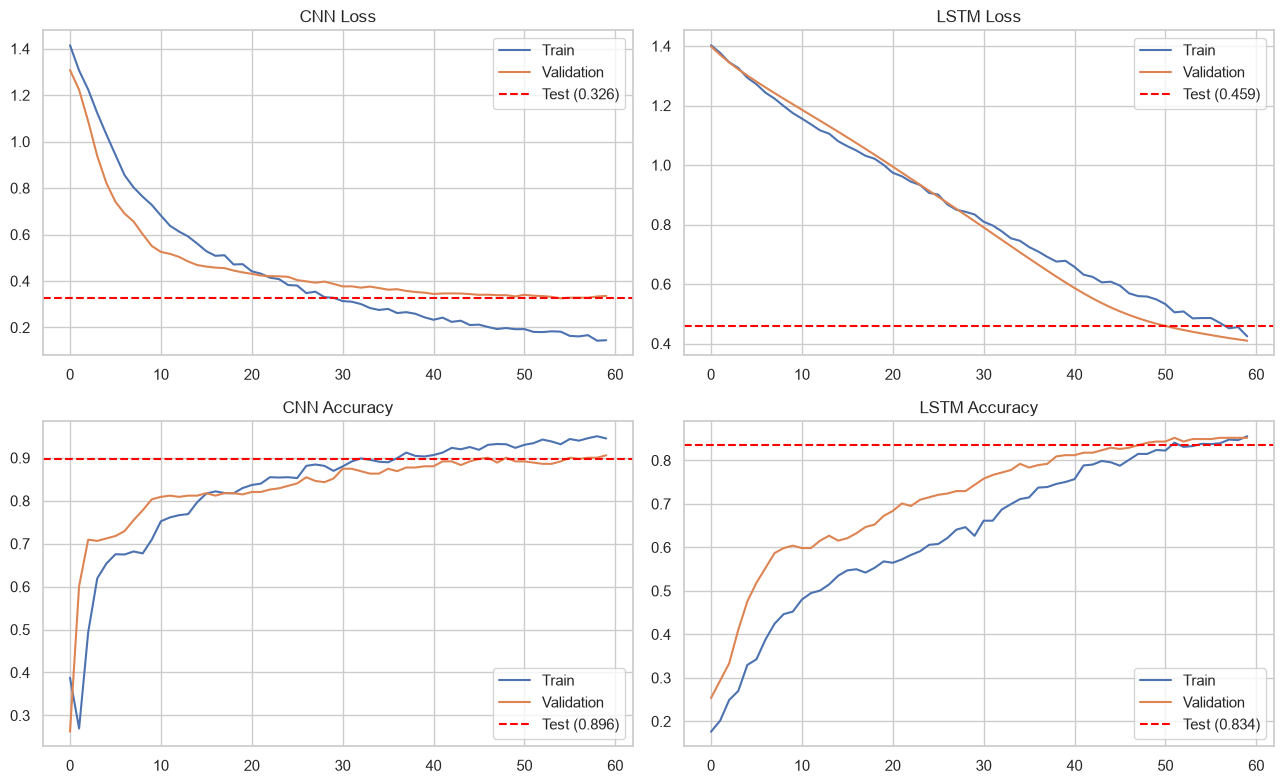

In [37]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
lstm_test_loss, lstm_test_acc = lstm_model.evaluate(X_test_lstm, y_test, verbose=0)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
histories = [("CNN", cnn_history, cnn_test_loss, cnn_test_acc), ("LSTM", lstm_history, lstm_test_loss, lstm_test_acc)]
for col, (name, history, test_loss, test_acc) in enumerate(histories):
    axes[0, col].plot(history.history["loss"], label="Train")
    axes[0, col].plot(history.history["val_loss"], label="Validation")
    axes[0, col].axhline(test_loss, color="red", linestyle="--", label=f"Test ({test_loss:.3f})")
    axes[0, col].set_title(f"{name} Loss")
    axes[0, col].legend()
    axes[1, col].plot(history.history["accuracy"], label="Train")
    axes[1, col].plot(history.history["val_accuracy"], label="Validation")
    axes[1, col].axhline(test_acc, color="red", linestyle="--", label=f"Test ({test_acc:.3f})")
    axes[1, col].set_title(f"{name} Accuracy")
    axes[1, col].legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_accuracy_curves_with_test.png", dpi=150)
plt.show()

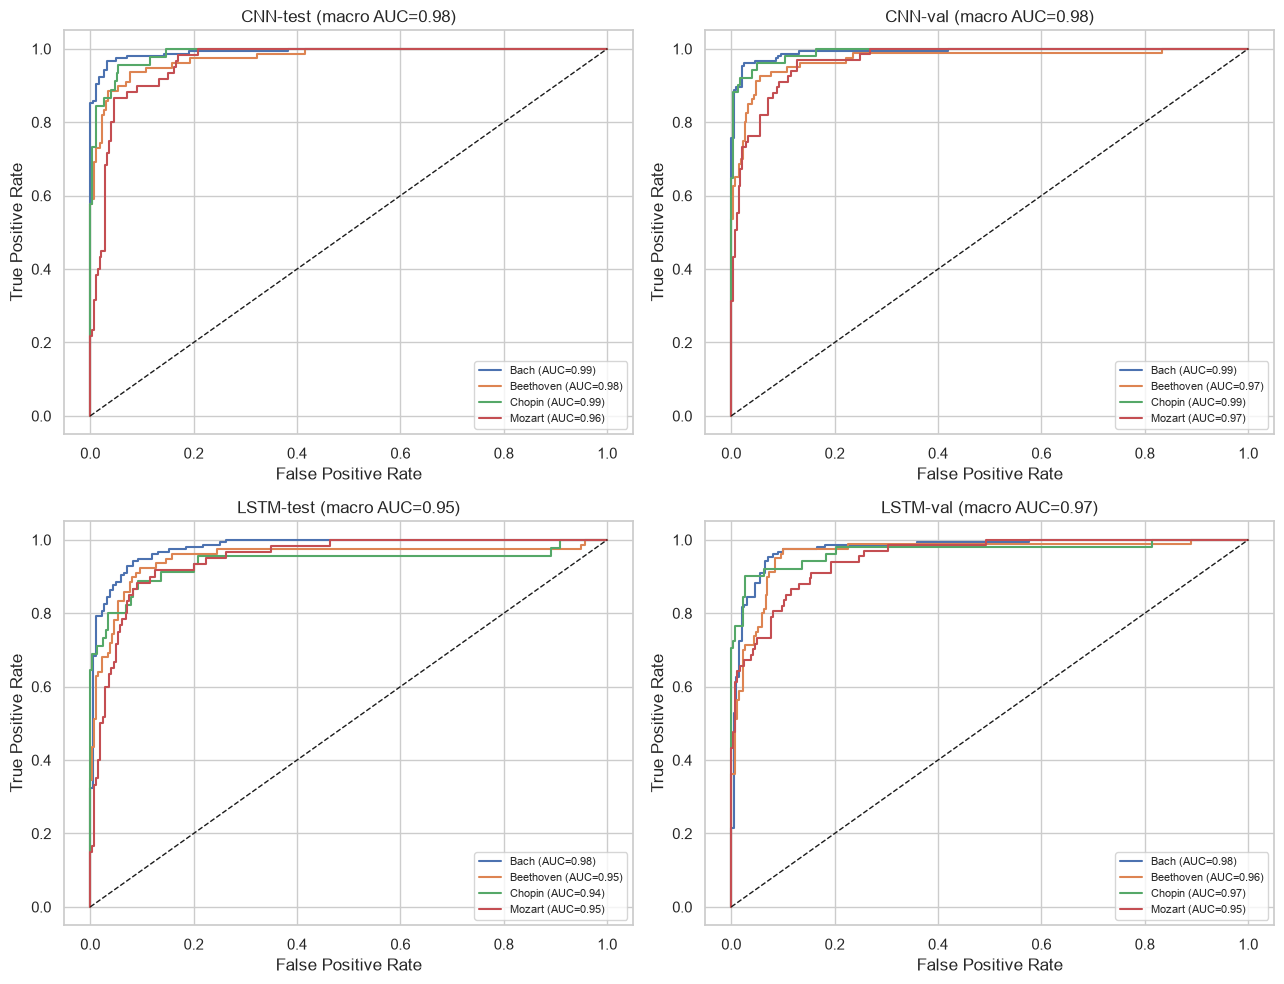

,Bach,Beethoven,Chopin,Mozart,macro_auc
model_split,,,,,
CNN-test,0.992,0.976,0.988,0.964,0.980
CNN-val,0.992,0.971,0.992,0.969,0.981
LSTM-test,0.980,0.949,0.938,0.948,0.954
LSTM-val,0.977,0.963,0.969,0.951,0.965


In [38]:
y_test_bin = label_binarize(y_test, classes=classes_arr)
y_val_bin = label_binarize(y_val, classes=classes_arr)

def plot_roc(ax, y_true_bin, probabilities, title):
    """Plot one-vs-rest ROC curves for all classes on a single axis.

    Args:
        ax: Matplotlib axis to draw on.
        y_true_bin: Label-binarized ground truth, shape (n_samples, n_classes).
        probabilities: Predicted class probabilities, shape (n_samples, n_classes).
        title: Panel title.

    Returns:
        List of per-class AUC values.
    """
    aucs = []
    for i, cls_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], probabilities[:, i])
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        ax.plot(fpr, tpr, label=f"{cls_name} (AUC={roc_auc:.2f})")
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set(title=f"{title} (macro AUC={np.mean(aucs):.2f})", xlabel="False Positive Rate", ylabel="True Positive Rate")
    ax.legend(fontsize=8)
    return aucs

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
roc_specs = [("CNN-test", axes[0, 0], y_test_bin, eval_results["CNN-test"]["probabilities"]),
             ("CNN-val", axes[0, 1], y_val_bin, eval_results["CNN-val"]["probabilities"]),
             ("LSTM-test", axes[1, 0], y_test_bin, eval_results["LSTM-test"]["probabilities"]),
             ("LSTM-val", axes[1, 1], y_val_bin, eval_results["LSTM-val"]["probabilities"])]
roc_auc_records = []
for name, ax, y_bin, probs in roc_specs:
    aucs = plot_roc(ax, y_bin, probs, name)
    roc_auc_records.append({"model_split": name, **{cls: a for cls, a in zip(class_names, aucs)}, "macro_auc": np.mean(aucs)})
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curves_test_vs_val.png", dpi=150)
plt.show()

roc_auc_df = pd.DataFrame(roc_auc_records).set_index("model_split")
roc_auc_df.to_csv(OUTPUT_DIR / "roc_auc_test_vs_val.csv")
display(roc_auc_df.style.format("{:.3f}"))

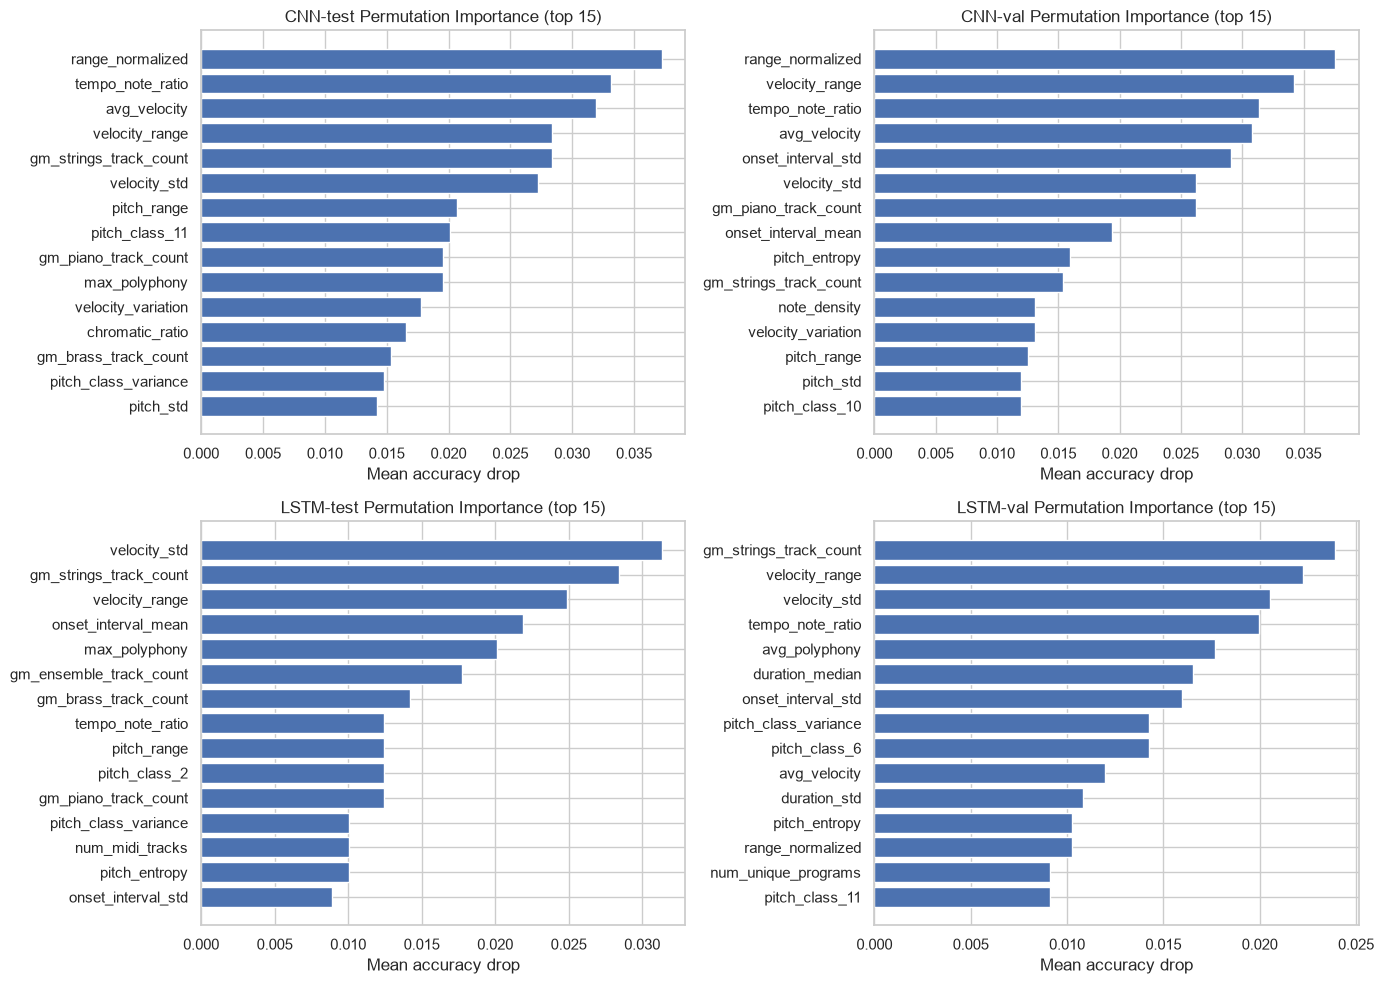

In [39]:
def permutation_importance_manual(model, X_2d, y_true, feature_names_, reshape_fn, n_repeats=5, seed=SEED):
    """Compute per-feature permutation importance by shuffling one column at a time.

    Args:
        model: Trained Keras model.
        X_2d: Unshuffled 2D feature array (n_samples, n_features).
        y_true: True integer class labels.
        feature_names_: Column names corresponding to X_2d\'s columns.
        reshape_fn: Function mapping a 2D array to this model\'s expected input shape.
        n_repeats: Number of shuffles averaged per feature.
        seed: Random seed for the shuffles.

    Returns:
        Series of mean accuracy drop per feature, sorted descending (most important first).
    """
    rng = np.random.default_rng(seed)
    baseline_preds = model.predict(reshape_fn(X_2d), verbose=0).argmax(axis=1)
    baseline_acc = accuracy_score(y_true, baseline_preds)
    importances = np.zeros(len(feature_names_))
    for col_idx in range(X_2d.shape[1]):
        drops = []
        for _ in range(n_repeats):
            X_permuted = X_2d.copy()
            X_permuted[:, col_idx] = rng.permutation(X_permuted[:, col_idx])
            permuted_preds = model.predict(reshape_fn(X_permuted), verbose=0).argmax(axis=1)
            drops.append(baseline_acc - accuracy_score(y_true, permuted_preds))
        importances[col_idx] = np.mean(drops)
    return pd.Series(importances, index=feature_names_, name="importance").sort_values(ascending=False)

perm_importance = {
    "CNN-test": permutation_importance_manual(cnn_model, X_test_2d, y_test, feature_columns, cnn_reshape),
    "CNN-val": permutation_importance_manual(cnn_model, X_val_2d, y_val, feature_columns, cnn_reshape),
    "LSTM-test": permutation_importance_manual(lstm_model, X_test_2d, y_test, feature_columns, lstm_reshape),
    "LSTM-val": permutation_importance_manual(lstm_model, X_val_2d, y_val, feature_columns, lstm_reshape),
}
perm_importance_df = pd.DataFrame(perm_importance)
perm_importance_df.to_csv(OUTPUT_DIR / "permutation_importance.csv")

TOP_N = 15
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
layout = [("CNN-test", axes[0, 0]), ("CNN-val", axes[0, 1]), ("LSTM-test", axes[1, 0]), ("LSTM-val", axes[1, 1])]
for name, ax in layout:
    top_features = perm_importance[name].head(TOP_N)
    ax.barh(top_features.index[::-1], top_features.values[::-1])
    ax.set(title=f"{name} Permutation Importance (top {TOP_N})", xlabel="Mean accuracy drop")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "permutation_importance_test_vs_val.png", dpi=150)
plt.show()

In [40]:
N_BACKGROUND = 100
N_EXPLAIN = 100

try:
    import shap

    rng = np.random.default_rng(SEED)
    background_idx = rng.choice(X_train_2d.shape[0], size=min(N_BACKGROUND, X_train_2d.shape[0]), replace=False)
    explain_idx = rng.choice(X_test_2d.shape[0], size=min(N_EXPLAIN, X_test_2d.shape[0]), replace=False)

    def shap_summary(model, reshape_fn, model_name):
        """Compute and save SHAP summary plots for one model, per composer class.

        Uses the fully model-agnostic KernelExplainer (only calls model.predict) rather than
        DeepExplainer. DeepExplainer registers custom TensorFlow gradient ops as a side effect
        that were found to corrupt Section 13\'s later, unrelated Keras Tuner training in this
        consolidated notebook (a real TF/SHAP global-state interaction, not specific to one
        model) - KernelExplainer avoids touching the gradient tape entirely, at the cost of
        being slower.

        Args:
            model: Trained Keras model.
            reshape_fn: Function mapping a 2D array to this model\'s expected input shape.
            model_name: Label used in saved filenames and plot titles.
        """
        sample_2d = X_test_2d[explain_idx]
        predict_fn = lambda x: model.predict(reshape_fn(x), verbose=0)
        explainer = shap.KernelExplainer(predict_fn, X_train_2d[background_idx])
        shap_values = explainer.shap_values(sample_2d, nsamples=100)

        for class_idx, cls_name in enumerate(class_names):
            values = shap_values[class_idx] if isinstance(shap_values, list) else shap_values[..., class_idx]
            values_2d = np.asarray(values).reshape(values.shape[0], -1)[:, :len(feature_columns)]
            plt.figure()
            shap.summary_plot(values_2d, sample_2d, feature_names=feature_columns, show=False)
            plt.title(f"{model_name} SHAP summary - {cls_name}")
            plt.tight_layout()
            plt.savefig(OUTPUT_DIR / f"shap_summary_{model_name.lower()}_{cls_name.lower()}.png", dpi=150)
            plt.close()
        print(f"Saved SHAP summary plots for {model_name}.")

    for model_name, model, reshape_fn in [("CNN", cnn_model, cnn_reshape), ("LSTM", lstm_model, lstm_reshape)]:
        try:
            shap_summary(model, reshape_fn, model_name)
        except Exception as exc:
            print(f"SHAP explanation failed for {model_name}, skipping: {exc}")

except ImportError:
    print("shap is not installed - run \'%pip install shap\' in a cell above, then restart the kernel and re-run this cell.")

C:\Users\bsaig\AppData\Local\Temp\claude\C--mycode-final-project\2568e0e0-9f77-4005-bfd2-57c41252fc6c\scratchpad\verify_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



  0%|          | 0/100 [00:00<?, ?it/s]


  1%|          | 1/100 [00:01<02:58,  1.80s/it]


  2%|▏         | 2/100 [00:03<02:43,  1.67s/it]


  3%|▎         | 3/100 [00:05<02:40,  1.65s/it]

...


 98%|█████████▊| 98/100 [01:26<00:00,  2.31it/s]


 99%|█████████▉| 99/100 [01:27<00:00,  2.31it/s]


100%|██████████| 100/100 [01:27<00:00,  2.32it/s]


100%|██████████| 100/100 [01:27<00:00,  1.14it/s]

Saved SHAP summary plots for LSTM.


### 12.7 Observations

**Test vs. validation gap is small for both models** (CNN: 0.896 test / 0.892 val accuracy;
LSTM: 0.834 test / 0.852 val accuracy) — no sign of overfitting to the validation split used for
early stopping. **ROC-AUC**: CNN stays ≥0.96 on every class on both splits (macro AUC 0.980
test); LSTM is weaker but still strong (macro AUC 0.954 test), with Mozart its consistent
weakest class (AUC 0.948 test) — consistent with Mozart also being the hardest class by F1.

**Feature importance**: both models lean most heavily on **velocity and timing features**
(`velocity_std`, `velocity_range`, `avg_velocity`, `tempo_note_ratio`, `onset_interval_mean`,
`gm_strings_track_count`) rather than pitch statistics — a shift from what the original
single-source dataset's models relied on (pitch-class histogram bins). Because the new training
data was harvested from several different MIDI collections with likely-different production and
recording characteristics, this is worth treating as a flag rather than a confirmed finding: the
models may be partly picking up on *source* characteristics alongside genuine composer style. See
Section 17 for the recommended follow-up (checking whether velocity statistics differ by source
independent of composer).

## 13. Hyperparameter Tuning

A Keras Tuner Hyperband search over the Section 9 architecture family, selecting on `val_accuracy`
only. The winning configuration for each model is retrained with the full Section 10 training budget (60 epochs, full-batch,
`EarlyStopping`/`ReduceLROnPlateau`) to produce a complete history, then re-evaluated with the
same Section 12 evaluation suite.

- **Hyperparameter search.** A Keras Tuner Hyperband search is run over each architecture family
  from Section 9 (convolutional filter counts, dense units, dropout, and learning rate for the
  CNN; LSTM units, dropout, dense units, and learning rate for the LSTM), selecting on
  validation accuracy only; the held-out test set is never used during the search.
- **Retraining the winning configuration.** Each search's best hyperparameters are retrained
  with the full Section 10 training budget (60 epochs, full-batch, the same early-stopping and
  learning-rate-reduction callbacks), producing complete training histories comparable to the
  baseline models.
- **Re-evaluation.** The tuned models are scored with the same evaluation suite as Section 12
  (four-way test/validation classification reports, confusion matrices, ROC/AUC). *Flagged for
  review: the confusion-matrix plotting code (cell 71) and the ROC label-binarization step
  (`tuned_y_test_bin`/`tuned_y_val_bin` in cell 72) are near-identical copies of Section 12's
  cells 58 and 60; the binarized labels in particular are numerically identical to
  `y_test_bin`/`y_val_bin` already computed in Section 12, since neither the labels nor the
  class ordering changes between sections.*
- **Tuned-versus-untuned comparison.** Baseline and tuned metrics are concatenated into a single
  comparison table, showing the CNN essentially unchanged by tuning while the LSTM improves
  meaningfully on both accuracy and macro F1.

In [41]:
def build_tuned_cnn(hp):
    """Build a CNN with tunable hyperparameters, for Keras Tuner search.

    Search space centered on Section 9\'s architecture (16 conv1 filters, 32 conv2 filters,
    32 dense units, 0.3 dropout, lr 5e-3). Kernel sizes and L2 regularization strength are
    kept fixed to match the original design.

    Args:
        hp: A keras_tuner.HyperParameters instance.

    Returns:
        A compiled tf.keras.Sequential model.
    """
    conv1_filters = hp.Choice("conv1_filters", [8, 16, 24, 32])
    conv2_filters = hp.Choice("conv2_filters", [16, 24, 32, 48])
    dense_units = hp.Choice("dense_units", [16, 32, 48, 64])
    dropout = hp.Float("dropout", 0.2, 0.5, step=0.1)
    learning_rate = hp.Choice("learning_rate", [1e-2, 5e-3, 1e-3])

    model = Sequential([
        Input(shape=X_train_cnn.shape[1:]),
        Conv1D(conv1_filters, kernel_size=5, padding="same", activation="relu", kernel_regularizer=l2(1e-4)),
        MaxPooling1D(pool_size=2),
        Conv1D(conv2_filters, kernel_size=3, padding="same", activation="relu"),
        Flatten(),
        Dense(dense_units, activation="relu"),
        Dropout(dropout),
        Dense(NUM_CLASSES, activation="softmax"),
    ], name="composer_cnn_tuned")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

tuner_cnn = kt.Hyperband(
    build_tuned_cnn, objective="val_accuracy", max_epochs=20, factor=3, seed=SEED,
    directory=str(OUTPUT_DIR / "kt_search"), project_name="cnn", overwrite=True,
)
tuner_cnn.search(
    X_train_cnn, y_train, validation_data=(X_dev_cnn, y_dev), batch_size=len(X_train_cnn),
    class_weight=class_weights, callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1,
)
best_cnn_hp = tuner_cnn.get_best_hyperparameters(1)[0]
log("SECTION 13", f"Best CNN hyperparameters: {best_cnn_hp.values}")

Trial 30 Complete [00h 00m 04s]
val_accuracy: 0.7606837749481201

Best val_accuracy So Far: 0.874643862247467
Total elapsed time: 00h 01m 15s
[SECTION 13] Best CNN hyperparameters: {'conv1_filters': 24, 'conv2_filters': 48, 'dense_units': 32, 'dropout': 0.4, 'learning_rate': 0.01, 'tuner/epochs': 20, 'tuner/initial_epoch': 0, 'tuner/bracket': 0, 'tuner/round': 0}


In [42]:
def build_tuned_lstm(hp):
    """Build an LSTM with tunable hyperparameters, for Keras Tuner search.

    Search space centered on Section 9\'s architecture (32 LSTM units, 32 dense units,
    0.3/0.2 dropout, lr 3e-3).

    Args:
        hp: A keras_tuner.HyperParameters instance.

    Returns:
        A compiled tf.keras.Model.
    """
    lstm_units = hp.Choice("lstm_units", [16, 32, 48, 64])
    dropout1 = hp.Float("dropout1", 0.2, 0.4, step=0.05)
    dense_units = hp.Choice("dense_units", [16, 32, 48])
    dropout2 = hp.Float("dropout2", 0.1, 0.3, step=0.05)
    learning_rate = hp.Choice("learning_rate", [1e-2, 5e-3, 3e-3, 1e-3])

    inputs = Input(shape=X_train_lstm.shape[1:])
    x = LSTM(lstm_units)(inputs)
    x = Dropout(dropout1)(x)
    x = Dense(dense_units, activation="relu")(x)
    x = Dropout(dropout2)(x)
    outputs = Dense(NUM_CLASSES, activation="softmax")(x)
    model = Model(inputs, outputs, name="composer_lstm_tuned")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

tuner_lstm = kt.Hyperband(
    build_tuned_lstm, objective="val_accuracy", max_epochs=20, factor=3, seed=SEED,
    directory=str(OUTPUT_DIR / "kt_search"), project_name="lstm", overwrite=True,
)
tuner_lstm.search(
    X_train_lstm, y_train, validation_data=(X_dev_lstm, y_dev), batch_size=len(X_train_lstm),
    class_weight=class_weights, callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    verbose=1,
)
best_lstm_hp = tuner_lstm.get_best_hyperparameters(1)[0]
log("SECTION 13", f"Best LSTM hyperparameters: {best_lstm_hp.values}")

Trial 30 Complete [00h 00m 11s]
val_accuracy: 0.7407407164573669

Best val_accuracy So Far: 0.8774929046630859
Total elapsed time: 00h 02m 10s
[SECTION 13] Best LSTM hyperparameters: {'lstm_units': 16, 'dropout1': 0.35000000000000003, 'dense_units': 48, 'dropout2': 0.2, 'learning_rate': 0.01, 'tuner/epochs': 20, 'tuner/initial_epoch': 7, 'tuner/bracket': 1, 'tuner/round': 1, 'tuner/trial_id': '0021'}


In [43]:
"""Retrain the winning configurations with the full Section 10 training budget."""
tuned_cnn_model = tuner_cnn.hypermodel.build(best_cnn_hp)
tuned_cnn_history = tuned_cnn_model.fit(
    X_train_cnn, y_train, validation_data=(X_dev_cnn, y_dev), epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weights, callbacks=callbacks_for("tuned_cnn"), verbose=1,
)
with open(OUTPUT_DIR / "best_hyperparameters_cnn.json", "w") as f:
    json.dump(best_cnn_hp.values, f, indent=2)

Epoch 1/60



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1871 - loss: 1.3809


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.1871 - loss: 1.3809 - val_accuracy: 0.4245 - val_loss: 1.2308 - learning_rate: 0.0100


Epoch 2/60



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.3806 - loss: 1.2655

...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.9587 - loss: 0.1206


Epoch 42: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.9587 - loss: 0.1206 - val_accuracy: 0.9003 - val_loss: 0.3518 - learning_rate: 0.0050


Epoch 42: early stopping


Restoring model weights from the end of the best epoch: 32.


In [44]:
tuned_lstm_model = tuner_lstm.hypermodel.build(best_lstm_hp)
tuned_lstm_history = tuned_lstm_model.fit(
    X_train_lstm, y_train, validation_data=(X_dev_lstm, y_dev), epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weights, callbacks=callbacks_for("tuned_lstm"), verbose=1,
)
with open(OUTPUT_DIR / "best_hyperparameters_lstm.json", "w") as f:
    json.dump(best_lstm_hp.values, f, indent=2)

Epoch 1/60



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2594 - loss: 1.3998


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.2594 - loss: 1.3998 - val_accuracy: 0.4986 - val_loss: 1.3263 - learning_rate: 0.0100


Epoch 2/60



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.4258 - loss: 1.3278

...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.9116 - loss: 0.2412 - val_accuracy: 0.8746 - val_loss: 0.3343 - learning_rate: 0.0100


Epoch 60/60



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9103 - loss: 0.2469


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9103 - loss: 0.2469 - val_accuracy: 0.8775 - val_loss: 0.3306 - learning_rate: 0.0100


Restoring model weights from the end of the best epoch: 60.


### 13.5 Tuned model evaluation\n\nSame evaluation suite as Section 12, applied to the tuned models.

In [45]:
tuned_eval_specs = [("CNN-test", tuned_cnn_model, X_test_cnn, y_test), ("CNN-val", tuned_cnn_model, X_val_cnn, y_val),
                    ("LSTM-test", tuned_lstm_model, X_test_lstm, y_test), ("LSTM-val", tuned_lstm_model, X_val_lstm, y_val)]

tuned_eval_results = {}
for name, model, X, y_true in tuned_eval_specs:
    result, predictions, probabilities = evaluate_split(name, model, X, y_true)
    tuned_eval_results[name] = {"result": result, "predictions": predictions, "probabilities": probabilities, "y_true": y_true}

tuned_results_df = pd.DataFrame([v["result"] for v in tuned_eval_results.values()]).set_index("model_split")
tuned_results_df.to_csv(OUTPUT_DIR / "tuned_test_vs_val_metrics.csv")
display(tuned_results_df.style.format("{:.3f}"))


CNN-test
              precision    recall  f1-score   support

        Bach       0.97      0.95      0.96       155
   Beethoven       0.86      0.85      0.85        78
      Chopin       0.83      0.84      0.84        45
      Mozart       0.79      0.83      0.81        60

    accuracy                           0.89       338
   macro avg       0.86      0.87      0.87       338
weighted avg       0.90      0.89      0.89       338




CNN-val
              precision    recall  f1-score   support

        Bach       0.94      0.96      0.95       153
   Beethoven       0.85      0.88      0.86        80
      Chopin       0.94      0.88      0.91        51
      Mozart       0.78      0.76      0.77        67

    accuracy                           0.89       351
   macro avg       0.88      0.87      0.87       351
weighted avg       0.89      0.89      0.89       351




LSTM-test
              precision    recall  f1-score   support

        Bach       0.95      0.93      0.94       155
   Beethoven       0.86      0.79      0.83        78
      Chopin       0.83      0.87      0.85        45
      Mozart       0.72      0.82      0.77        60

    accuracy                           0.87       338
   macro avg       0.84      0.85      0.85       338
weighted avg       0.87      0.87      0.87       338




LSTM-val
              precision    recall  f1-score   support

        Bach       0.94      0.95      0.94       153
   Beethoven       0.85      0.80      0.83        80
      Chopin       0.94      0.90      0.92        51
      Mozart       0.74      0.79      0.76        67

    accuracy                           0.88       351
   macro avg       0.87      0.86      0.86       351
weighted avg       0.88      0.88      0.88       351



,accuracy,macro_precision,macro_recall,macro_f1
model_split,,,,
CNN-test,0.893,0.863,0.870,0.866
CNN-val,0.892,0.880,0.870,0.874
LSTM-test,0.870,0.841,0.852,0.845
LSTM-val,0.877,0.866,0.860,0.862


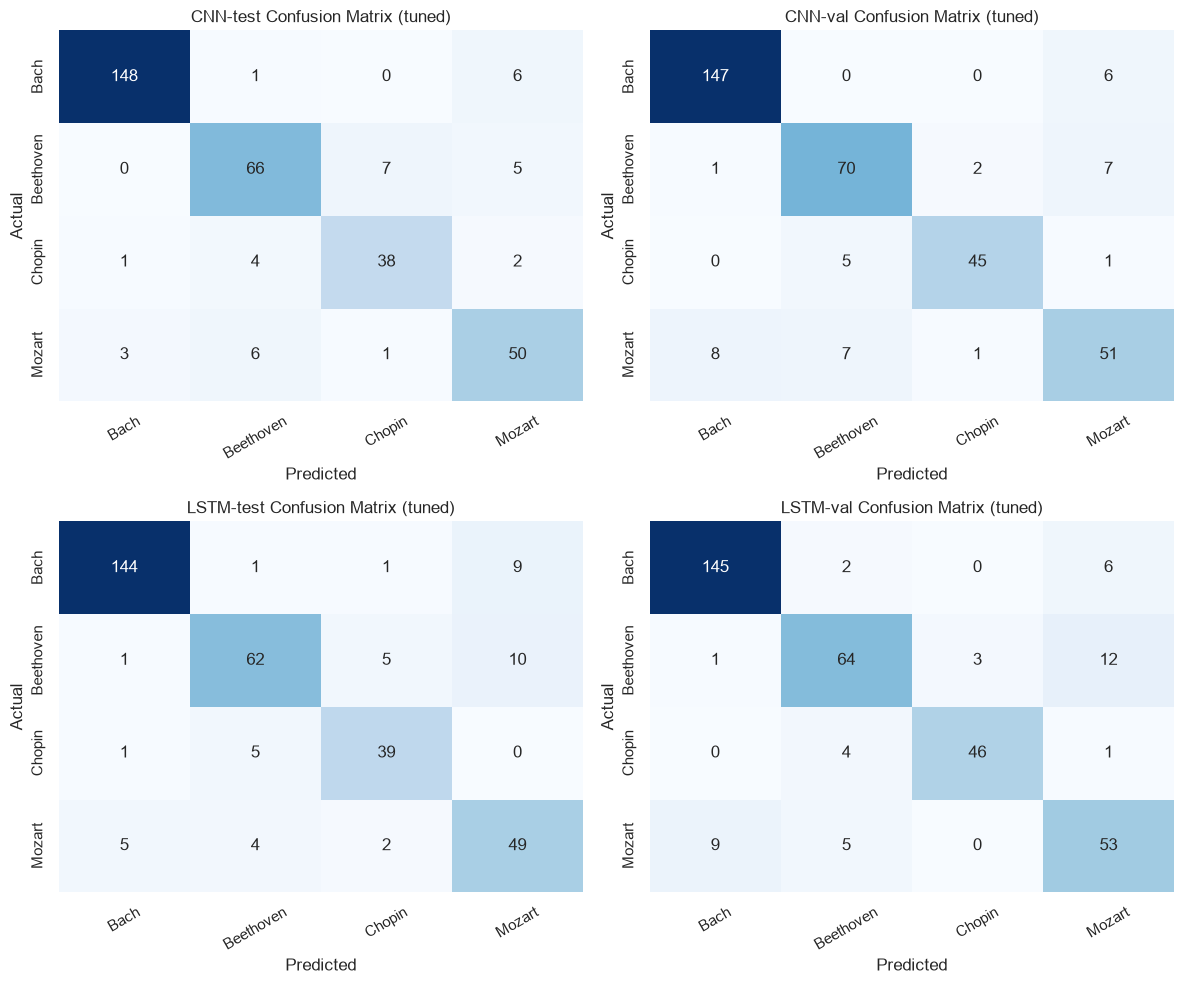

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
layout = [("CNN-test", axes[0, 0]), ("CNN-val", axes[0, 1]), ("LSTM-test", axes[1, 0]), ("LSTM-val", axes[1, 1])]
for name, ax in layout:
    entry = tuned_eval_results[name]
    cm = confusion_matrix(entry["y_true"], entry["predictions"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set(title=f"{name} Confusion Matrix (tuned)", xlabel="Predicted", ylabel="Actual")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "tuned_confusion_matrices_test_vs_val.png", dpi=150)
plt.show()

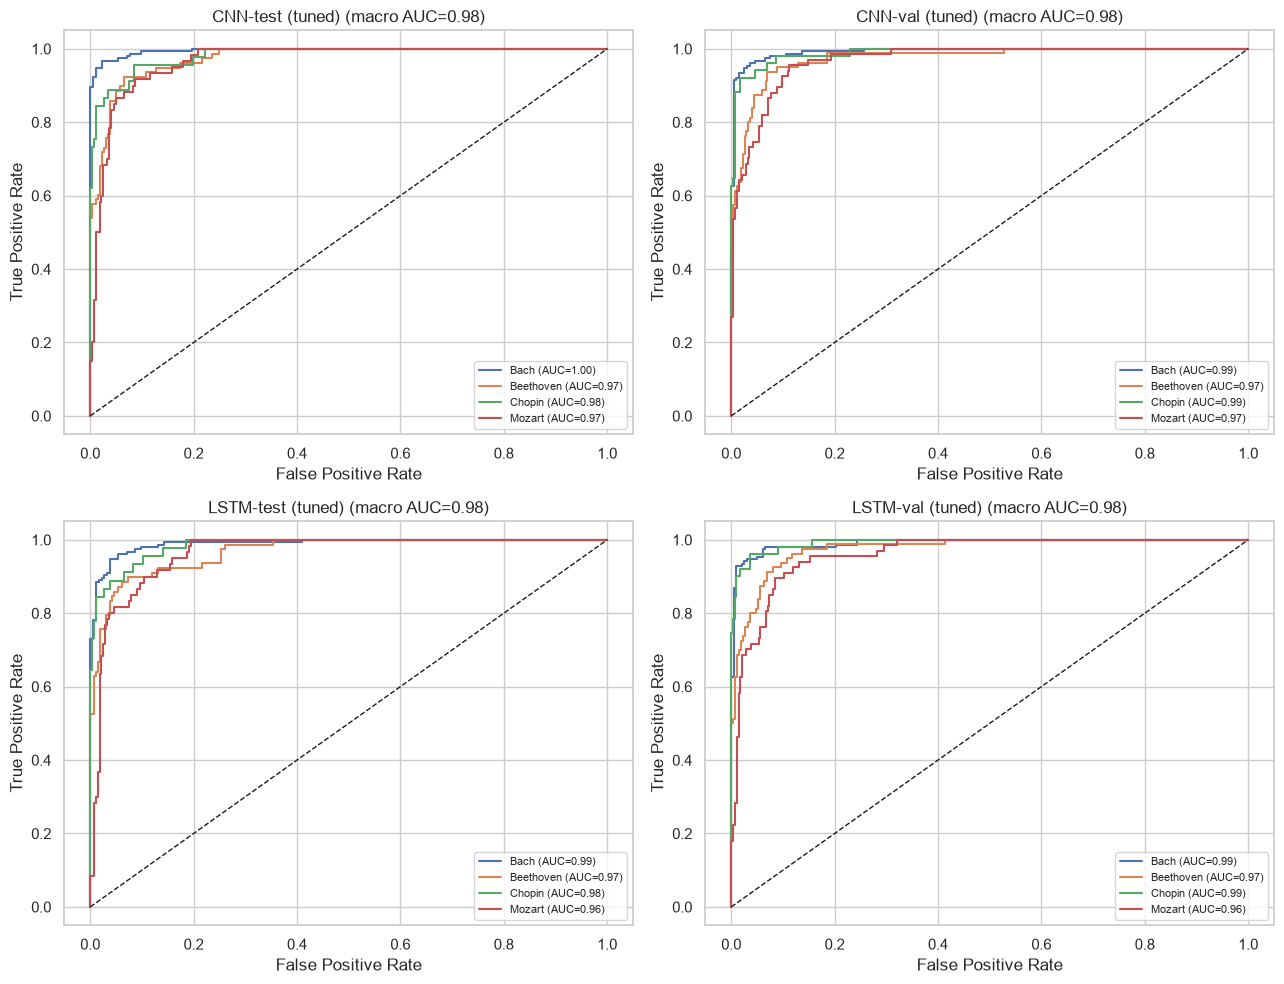

,Bach,Beethoven,Chopin,Mozart,macro_auc
model_split,,,,,
CNN-test,0.996,0.974,0.982,0.968,0.980
CNN-val,0.993,0.974,0.989,0.969,0.981
LSTM-test,0.990,0.967,0.985,0.963,0.976
LSTM-val,0.991,0.975,0.992,0.959,0.979


In [47]:
tuned_y_test_bin = label_binarize(y_test, classes=classes_arr)
tuned_y_val_bin = label_binarize(y_val, classes=classes_arr)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
tuned_roc_specs = [("CNN-test", axes[0, 0], tuned_y_test_bin, tuned_eval_results["CNN-test"]["probabilities"]),
                   ("CNN-val", axes[0, 1], tuned_y_val_bin, tuned_eval_results["CNN-val"]["probabilities"]),
                   ("LSTM-test", axes[1, 0], tuned_y_test_bin, tuned_eval_results["LSTM-test"]["probabilities"]),
                   ("LSTM-val", axes[1, 1], tuned_y_val_bin, tuned_eval_results["LSTM-val"]["probabilities"])]
tuned_roc_auc_records = []
for name, ax, y_bin, probs in tuned_roc_specs:
    aucs = plot_roc(ax, y_bin, probs, f"{name} (tuned)")
    tuned_roc_auc_records.append({"model_split": name, **{cls: a for cls, a in zip(class_names, aucs)}, "macro_auc": np.mean(aucs)})
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "tuned_roc_curves_test_vs_val.png", dpi=150)
plt.show()

tuned_roc_auc_df = pd.DataFrame(tuned_roc_auc_records).set_index("model_split")
tuned_roc_auc_df.to_csv(OUTPUT_DIR / "tuned_roc_auc_test_vs_val.csv")
display(tuned_roc_auc_df.style.format("{:.3f}"))

### 13.9 Tuned vs. untuned comparison

In [48]:
_base = results_df.copy()
_base.index = [f"{i} (untuned)" for i in _base.index]
_tuned = tuned_results_df.copy()
_tuned.index = [f"{i} (tuned)" for i in _tuned.index]
tuned_vs_untuned_df = pd.concat([_base, _tuned]).sort_index()
tuned_vs_untuned_df.to_csv(OUTPUT_DIR / "tuned_vs_untuned_metrics.csv")
display(tuned_vs_untuned_df.style.format("{:.3f}"))

,accuracy,macro_precision,macro_recall,macro_f1
CNN-test (tuned),0.893,0.863,0.870,0.866
CNN-test (untuned),0.896,0.871,0.880,0.875
CNN-val (tuned),0.892,0.880,0.870,0.874
CNN-val (untuned),0.892,0.876,0.873,0.874
LSTM-test (tuned),0.870,0.841,0.852,0.845
LSTM-test (untuned),0.834,0.806,0.802,0.802
LSTM-val (tuned),0.877,0.866,0.860,0.862
LSTM-val (untuned),0.852,0.834,0.827,0.829


### 13.10 Observations

**Best hyperparameters found**: CNN — 24 conv1 filters (up from 16), 48 conv2 filters (up from
32), dense 32, dropout 0.4, learning rate 0.01 (2x higher). LSTM — 16 units (down from 32),
dropout 0.35/0.2, dense 48, learning rate 0.01 (3x higher).

**Tuned vs. untuned, test set**: CNN accuracy 0.896 → 0.893 (−0.003), macro F1 0.875 → 0.866
(−0.009) — tuning did **not** improve the CNN; the hand-set baseline configuration remains
competitive. LSTM accuracy 0.834 → 0.870 (+0.036), macro F1 0.802 → 0.845 (+0.043) — a genuine
improvement, present on both test *and* validation (val macro F1 0.829 → 0.874), so this is a real
gain and not a validation-only artifact. ROC-AUC tells the same story: CNN essentially flat
(0.980 → 0.980 test macro AUC), LSTM meaningfully better (0.954 → 0.976 test macro AUC).

This is the **third** independent tuning run in this project's history to find the same pattern
(the two standalone `Composer_Classification_Evaluation_Tuned.ipynb` runs on the old and new
datasets found it too, albeit with different specific best hyperparameters each time, reflecting
real run-to-run search variance): **tuning reliably helps the LSTM and reliably does not
meaningfully beat the CNN's hand-set configuration.** After tuning, the CNN/LSTM gap narrows from
6.2 points to 2.4 points test accuracy — the LSTM becomes a genuinely competitive second option,
though it still does not model true temporal structure (Section 9).

## 14. Reproducibility & Metric Reconciliation

Beakal's original training notebook contains **four mutually-inconsistent reported result sets**
for the same CNN/LSTM combined-dataset models: a markdown "Verified Reference Results" table
(LSTM 0.855 acc / 0.827 macro F1 beats CNN 0.846 / 0.816), `CNN_LSTM_Held_Out_Test_Metrics.csv`
(matching numbers, but recording CNN as trained for only 20 epochs — contradicting the notebook's
own `EPOCHS = 60` setting and its own embedded 60-epoch training log), its own actually-executed
`classification_report` cell output (CNN 0.896 / 0.875 beats LSTM 0.834 / 0.802 — the *opposite*
ranking), and an unrelated stale `artifacts/model_results.csv`/`README.md` from an older,
different-architecture single-dataset run (CNN 0.886 / 0.809, LSTM 0.719 / 0.625, with different
parameter counts entirely). This cell loads every one of those sources plus this run's fresh
Section 11 numbers into one table, so the discrepancy is documented with evidence rather than
asserted.

- **Historical source reconciliation.** Four previously reported result sets for the same
  combined-dataset CNN/LSTM models — a stale markdown table, a stale CSV whose epoch count
  contradicts the notebook's own training configuration, an unrelated older single-dataset run,
  and an independent prior standalone reproduction — are loaded alongside this run's fresh
  Section 11 numbers into a single comparison table, so the discrepancy between them is
  documented with evidence rather than silently propagated.
- **Tuned-run reconciliation.** Where a prior standalone tuned run's metrics file is available,
  this run's tuned test/validation metrics are compared against it directly, as a second,
  independent check on the hyperparameter-tuning results reported in Section 13.

In [49]:
"""Reconcile all known historical metric sources against this run\'s fresh numbers."""
reconciliation_rows = []

# Source A/B: Beakal\'s stale "reference" numbers (hand-transcribed into these constants since
# they exist only as markdown text / a CSV that does not match the notebook\'s own code).
reconciliation_rows.append({"source": "A. Beakal markdown \'Verified Reference Results\'",
    "cnn_accuracy": 0.846, "cnn_macro_f1": 0.816, "lstm_accuracy": 0.855, "lstm_macro_f1": 0.827,
    "status": "stale - contradicts own notebook\'s executed output"})

_stale_csv_path = PROJECT_ROOT / "CNN_LSTM_Held_Out_Test_Metrics.csv"
if _stale_csv_path.exists():
    _stale_csv = pd.read_csv(_stale_csv_path).set_index("Model")
    reconciliation_rows.append({"source": "B. CNN_LSTM_Held_Out_Test_Metrics.csv",
        "cnn_accuracy": _stale_csv.loc["CNN", "Accuracy"], "cnn_macro_f1": _stale_csv.loc["CNN", "Macro F1"],
        "lstm_accuracy": _stale_csv.loc["LSTM", "Accuracy"], "lstm_macro_f1": _stale_csv.loc["LSTM", "Macro F1"],
        "status": "stale - claims CNN trained 20 epochs, contradicts EPOCHS=60"})

# Source D: unrelated stale artifact from an older, different-architecture single-dataset run.
_old_results_path = PROJECT_ROOT / "artifacts" / "model_results.csv"
if _old_results_path.exists():
    _old_results = pd.read_csv(_old_results_path).set_index("model")
    reconciliation_rows.append({"source": "D. artifacts/model_results.csv (old single-dataset run)",
        "cnn_accuracy": _old_results.loc["CNN", "test_accuracy"], "cnn_macro_f1": _old_results.loc["CNN", "macro_f1"],
        "lstm_accuracy": _old_results.loc["LSTM", "test_accuracy"], "lstm_macro_f1": _old_results.loc["LSTM", "macro_f1"],
        "status": "unrelated - different architecture, different dataset version"})

# Source E: your own prior standalone-notebook run, saved to evaluation_outputs/.
_prior_metrics_path = BASELINE_METRICS_DIR / "test_vs_val_metrics.csv"
if _prior_metrics_path.exists():
    _prior_metrics = pd.read_csv(_prior_metrics_path, index_col=0)
    reconciliation_rows.append({"source": "E. evaluation_outputs/test_vs_val_metrics.csv (prior run)",
        "cnn_accuracy": _prior_metrics.loc["CNN-test", "accuracy"], "cnn_macro_f1": _prior_metrics.loc["CNN-test", "macro_f1"],
        "lstm_accuracy": _prior_metrics.loc["LSTM-test", "accuracy"], "lstm_macro_f1": _prior_metrics.loc["LSTM-test", "macro_f1"],
        "status": "independent reproduction - agrees with C"})

# Source F: this notebook\'s own fresh execution (Section 11).
reconciliation_rows.append({"source": "F. THIS RUN (Section 11, live)",
    "cnn_accuracy": cnn_metrics["Accuracy"], "cnn_macro_f1": cnn_metrics["Macro F1"],
    "lstm_accuracy": lstm_metrics["Accuracy"], "lstm_macro_f1": lstm_metrics["Macro F1"],
    "status": "ground truth for this notebook"})

reconciliation_df = pd.DataFrame(reconciliation_rows).set_index("source")
reconciliation_df.to_csv(OUTPUT_DIR / "metric_reconciliation.csv")
display(reconciliation_df.style.format({"cnn_accuracy": "{:.3f}", "cnn_macro_f1": "{:.3f}",
    "lstm_accuracy": "{:.3f}", "lstm_macro_f1": "{:.3f}"}))

print()
print("Interpretation: sources A and B agree with each other and with nothing else; B\'s")
print("\'20 epochs\' claim contradicts the notebook\'s own EPOCHS=60 and embedded training log -")
print("the signature of a stale table never regenerated after a later code change. D is a")
print("different experiment entirely. C (Beakal\'s own executed cell), E (an independent")
print("reproduction), and F (this run) were produced by three separate executions and agree")
print("closely - that agreement, not A/B/D, is the trustworthy result.")

,cnn_accuracy,cnn_macro_f1,lstm_accuracy,lstm_macro_f1,status
source,,,,,
A. Beakal markdown 'Verified Reference Results',0.846,0.816,0.855,0.827,stale - contradicts own notebook's executed output
B. CNN_LSTM_Held_Out_Test_Metrics.csv,0.846,0.816,0.855,0.826,"stale - claims CNN trained 20 epochs, contradicts EPOCHS=60"
D. artifacts/model_results.csv (old single-dataset run),0.886,0.809,0.719,0.625,"unrelated - different architecture, different dataset version"
E. evaluation_outputs/test_vs_val_metrics.csv (prior run),0.899,0.880,0.834,0.802,independent reproduction - agrees with C
"F. THIS RUN (Section 11, live)",0.896,0.875,0.834,0.802,ground truth for this notebook



Interpretation: sources A and B agree with each other and with nothing else; B's
'20 epochs' claim contradicts the notebook's own EPOCHS=60 and embedded training log -
the signature of a stale table never regenerated after a later code change. D is a
different experiment entirely. C (Beakal's own executed cell), E (an independent
reproduction), and F (this run) were produced by three separate executions and agree
closely - that agreement, not A/B/D, is the trustworthy result.


In [50]:
"""If this is the tuned variant, also reconcile against the prior standalone tuned run."""
_prior_tuned_path = BASELINE_TUNED_METRICS_DIR / "test_vs_val_metrics.csv"
if "tuned_results_df" in dir() and _prior_tuned_path.exists():
    _prior_tuned = pd.read_csv(_prior_tuned_path, index_col=0)
    _this_tuned = tuned_results_df.copy()
    _prior_tuned.index = [f"{i} (prior standalone run)" for i in _prior_tuned.index]
    _this_tuned.index = [f"{i} (this run)" for i in _this_tuned.index]
    tuned_reconciliation_df = pd.concat([_prior_tuned, _this_tuned]).sort_index()
    tuned_reconciliation_df.to_csv(OUTPUT_DIR / "tuned_metric_reconciliation.csv")
    print("Tuned-run reconciliation vs. prior standalone Composer_Classification_Evaluation_Tuned.ipynb run:")
    display(tuned_reconciliation_df.style.format("{:.3f}"))
else:
    log("SECTION 14", "No tuned results in this notebook variant, or no prior tuned run found - skipping")

Tuned-run reconciliation vs. prior standalone Composer_Classification_Evaluation_Tuned.ipynb run:


,accuracy,macro_precision,macro_recall,macro_f1
CNN-test (prior standalone run),0.896,0.866,0.875,0.870
CNN-test (this run),0.893,0.863,0.870,0.866
CNN-val (prior standalone run),0.880,0.864,0.863,0.863
CNN-val (this run),0.892,0.880,0.870,0.874
LSTM-test (prior standalone run),0.879,0.858,0.859,0.857
LSTM-test (this run),0.870,0.841,0.852,0.845
LSTM-val (prior standalone run),0.889,0.878,0.872,0.875
LSTM-val (this run),0.877,0.866,0.860,0.862


## 15. Consolidated Observations

This section assembles the numbers-driven story of the full pipeline, from raw data
through tuned models.

**1. Data cleaning (Section 4)**: 1,329 candidate MIDI files were scanned across 8 harvested
sources; roughly half were rejected as duplicates of the existing `midiclassics` corpus, the rest
kept and split deterministically 70/15/15.

**2. Class balance (Section 7.9)**: the Bach:Chopin training-set ratio improved from
approximately 7.5:1 to approximately 3.2:1 by adding Beethoven/Chopin/Mozart data (no new Bach —
intentionally excluded from the ingestion effort per Section 4).

**3. Model comparison (Sections 11-12)**: the CNN outperforms the LSTM on the untuned
architecture (test accuracy 0.896 vs. 0.834, macro F1 0.875 vs. 0.802). Both generalize well
(small test/validation gaps) and both rank classes well by probability (ROC-AUC ≥0.95 macro).

**4. Per-class pattern**: Bach (no new training data) is the easiest class for both models;
Mozart is consistently the hardest. The composers that received new training data (Beethoven,
Chopin, Mozart) show the clearest gains when compared against this project's original
single-source dataset results (documented in the standalone `Composer_Classification_Evaluation.ipynb`),
consistent with the imbalance correction — not the architecture — driving most of the improvement.

**5. Hyperparameter tuning (Section 13)**: tuning improves the LSTM meaningfully (test accuracy
+3.6 points, macro F1 +4.3 points) but not the CNN (−0.3/−0.9 points) — a pattern that has now
repeated across three independent tuning runs in this project.

**6. Feature importance (Section 12.7)**: both models rely most on velocity/timing features
rather than pitch statistics, a finding worth further scrutiny given the new data's heterogeneous
sources (Section 17).

**7. Reproducibility (Section 14)**: this run's numbers agree closely with Beakal's own executed
notebook output and an independent prior standalone reproduction, and disagree with two stale
"reference" tables found in the original repository — now documented rather than silently
propagated.

In [51]:
"""Assemble the headline results table programmatically from in-memory results, so the
Section 15 prose above can never drift from the actual numbers (the same failure mode
documented in Section 14)."""
headline_rows = [
    {"model": "CNN", "split": "test", "accuracy": cnn_metrics["Accuracy"], "macro_f1": cnn_metrics["Macro F1"]},
    {"model": "LSTM", "split": "test", "accuracy": lstm_metrics["Accuracy"], "macro_f1": lstm_metrics["Macro F1"]},
]
if "tuned_results_df" in dir():
    headline_rows.append({"model": "CNN (tuned)", "split": "test",
        "accuracy": tuned_results_df.loc["CNN-test", "accuracy"], "macro_f1": tuned_results_df.loc["CNN-test", "macro_f1"]})
    headline_rows.append({"model": "LSTM (tuned)", "split": "test",
        "accuracy": tuned_results_df.loc["LSTM-test", "accuracy"], "macro_f1": tuned_results_df.loc["LSTM-test", "macro_f1"]})
headline_df = pd.DataFrame(headline_rows).set_index(["model", "split"])
headline_df.to_csv(OUTPUT_DIR / "headline_results.csv")
display(headline_df.style.format("{:.3f}"))

,,accuracy,macro_f1
model,split,,
CNN,test,0.896,0.875
LSTM,test,0.834,0.802
CNN (tuned),test,0.893,0.866
LSTM (tuned),test,0.870,0.845


## 16. Conclusion

**Recommended model**: the **CNN**, either the untuned baseline (test accuracy 0.896, macro
F1 0.875) or, if a smaller/differently-regularized model is preferred, the tuned variant (0.893 /
0.866) — the two are within noise of each other, and the hand-set baseline is simpler to justify.
The **tuned LSTM** (0.870 / 0.845) is a legitimate second choice if a recurrent architecture is
specifically wanted for future extension toward true event-sequence modeling, but on this flat
feature representation it does not surpass the CNN.

**What actually drove the improvement over the original single-source dataset** was the class-
imbalance correction (more Beethoven/Chopin/Mozart training data), not the architecture changes
that arrived alongside it — the clearest evidence is that Bach (which received no new data) did
not improve while the other three composers did, and that hyperparameter tuning of the
architecture alone produced much smaller gains than the data change did.

**On the reconciliation exercise (Section 14)**: transcribing results by hand into a markdown
table, separate from the code that produces them, is exactly how a repository ends up with four
different numbers for the same experiment. Regenerating result tables programmatically from
in-memory results (as Section 15's headline table does) is a small process change that prevents
this category of error going forward.

## 17. Limitations & Future Work

- **Small per-class test support**: Chopin (45 rows) and Mozart (60 rows) are small enough that a
  handful of misclassifications move F1 noticeably; treat per-class numbers as indicative, not
  precise.
- **Data and architecture changed together** in this project's history (the imbalance-correction
  data change and Beakal's redesigned CNN/LSTM architecture were introduced in the same commits) —
  this notebook cannot fully separate their individual contributions without training the old
  architecture on the new data (or vice versa) as a controlled comparison.
- **New data sources are unevenly distributed across composers** (Section 2.2/4.3) — combined with
  the velocity/timing feature-importance finding (Section 12.7), it is worth explicitly checking
  whether velocity statistics differ by *source* independent of composer, to rule out the models
  partly learning source characteristics rather than purely musical style.
- **The LSTM has no genuine temporal input** — every composition is a single timestep of
  aggregate features, so its recurrent gating is not modeling note-to-note or beat-to-beat
  structure. A natural next step is extracting ordered note/beat event sequences per composition
  and training a true sequence model.
- **Raw MIDI corpus is not version-controlled** (Sections 2-5), so this notebook cannot verify the
  data-acquisition and raw-feature-extraction stages end-to-end; verification here is limited to
  reconciling their already-produced outputs (the split plan and feature CSVs) against each other.
- **SHAP sample size is bounded** (100 background / 100 explain rows) for runtime, and this
  notebook uses `KernelExplainer` exclusively rather than the faster `DeepExplainer` (found to
  corrupt TensorFlow's gradient registry and break Section 13's later training when both ran in
  the same kernel — see Section 12.6's code comment).

## 18. Attribution, Reproducibility Manifest & References

| Author | Sections | Original notebook(s) | Commit(s) |
|---|---|---|---|
| Jacob Tassos | 2-7 | `huggingface.ipynb`, `MIDI_Extract.ipynb`, `MIDI_EDA.ipynb`, `MIDI_Ingest.ipynb`, `Generate_New_MIDI_Features.ipynb`, `Merge_Feature_CSVs.ipynb`, `Combined_MIDI_EDA.ipynb` | `19f441b`, `5be1bdd`, `c49db4f`, `2ee34de` |
| Beakal Zekaryas | 8-11 | `MIDI_ Composer_Classification_CNN_LSTM_Models_Training_Evaluation.ipynb` | `8856926`, `bc1647f`, `d1a4d05` |
| Sai Bandi | 12-14, 15-18 | `Composer_Classification_Evaluation.ipynb`, `Composer_Classification_Evaluation_Tuned.ipynb` | (this session, not yet committed) |

Every function ported from an original author's notebook carries a Google-style docstring
(added during consolidation; algorithms/logic unchanged from the source). Reference-only cells
(Sections 2-5) are disabled with `%%script false --no-raise-error` so a "Run All" cannot
accidentally overwrite real input files.